# parse_gfa.py — Step-by-step exploration

Follows the execution path of `parse_gfa.py main()` cell-by-cell,
visualising intermediate results at each stage.

**Input data:** `genome-blender_run/tiny` (200 PE reads, 2 genomes, 150 bp)

> **Prerequisite:** The tiny dataset must have been run with rust-mdbg
> `--dump-read-minimizers` to produce `rust_mdbg_out.index.lmdb`.
> If it is missing, run the setup cell below.

## 0  Setup
### Paths and imports

In [2]:
import json
import logging
import random
import struct
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import rustworkx as rx
import lmdb

logging.basicConfig(level=logging.INFO, format="%(levelname)s %(message)s")

# ── paths ────────────────────────────────────────────────────────────────────
FP = Path("../../genome-blender_run/single_short_shallow/output/rust-mdbg").resolve()
PREFIX      = FP / "rust_mdbg_out"
READS_STATS = FP / "reads_stats.json"
GFA         = PREFIX.with_suffix(".gfa")
MIN_TABLE   = PREFIX.with_name(PREFIX.name + ".minimizer_table")
LMDB_PATH   = PREFIX.with_name(PREFIX.name + ".index.lmdb")   # produced by --dump-read-minimizers
PE_LMDB     = PREFIX.with_name(PREFIX.name + ".pe_index.lmdb")
INTRA_LMDB  = PREFIX.with_name(PREFIX.name + ".intra_index.lmdb")
READS_FILE  = FP / "combined_reads.fastq"

# rust-mdbg parameters — mirror run_rust_mdbg.sh
mdbg_K        = 7      # minimizer k-mer order (--combo-k)
K             = 0
L             = 21     # l-mer length
MINABUND      = 2
COMBO_DENSITY = 0.1
INSERT_BINS   = [0, 200, 400, 800, 1200, 2000, 3000, 6000]

print("Read stats exists:", READS_STATS.exists())
print("GFA exists:",        GFA.exists())
print("LMDB exists:",       LMDB_PATH.exists())
print("Min table exists:",  MIN_TABLE.exists())

Read stats exists: True
GFA exists: True
LMDB exists: True
Min table exists: True


In [3]:
# ── optional: regenerate read_stats output ───────────
# Run this cell only if READS_STATS is missing.  Requires the rust-mdbg binary.

if not READS_STATS.exists():
    import subprocess, shutil

    READS_STATS_JSON="${OUTPUT_DIR}/reads_stats.json"
    PYTHON = "/Users/timrozday/miniforge3/envs/genome_blender_dev/bin/python"
    READS_SUMMARY_SCRIPT = "../scripts/reads_summary.py"  \

    cmd = [
        str(PYTHON),
        str(READS_SUMMARY_SCRIPT),
        str(READS_FILE),
        "-n 1000",
        f"--json {READS_STATS}"
    ]
    print("Running:", " ".join(cmd))
    result = subprocess.run(cmd, capture_output=True, text=True)
    print(result.stdout[-2000:] if result.stdout else "(no stdout)")
    if result.returncode != 0:
        print("STDERR:", result.stderr[-2000:])
    else:
        print("Done.  Read stats exists:", READS_STATS.exists())
else:
    print("Read stats already present — skipping run.")

Read stats already present — skipping run.


In [4]:
# ── optional: regenerate rust-mdbg output including the LMDB index ───────────
# Run this cell only if LMDB_PATH is missing.  Requires the rust-mdbg binary.

if not LMDB_PATH.exists():
    import subprocess, shutil
    RUSTMDBG = Path("../bin/rust-mdbg").resolve()
    READS_STATS = TINY / "reads_stats.json"

    # Estimate density from read length
    stats = json.loads(READS_STATS.read_text())
    mean_read_len = int(stats["mean"] + 0.5)
    density = f"{L / (mean_read_len * 0.75):.4f}"
    print(f"mean_read_len={mean_read_len}  density={density}")

    R1 = FP.parent / "sim_reads_R1.fastq"
    R2 = FP.parent / "sim_reads_R2.fastq"

    cmd = [
        str(RUSTMDBG),
        str(R1), "--reads2", str(R2),
        "-k", str(mdbg_K),
        "--density", density,
        "-l", str(L),
        "--minabund", str(MINABUND),
        "--prefix", str(PREFIX),
        "--dump-read-minimizers",
    ]
    print("Running:", " ".join(cmd))
    result = subprocess.run(cmd, capture_output=True, text=True)
    print(result.stdout[-2000:] if result.stdout else "(no stdout)")
    if result.returncode != 0:
        print("STDERR:", result.stderr[-2000:])
    else:
        print("Done.  LMDB exists:", LMDB_PATH.exists())
else:
    print("LMDB already present — skipping rust-mdbg run.")

LMDB already present — skipping rust-mdbg run.


### Functions

All functions from `scripts/parse_gfa.py` are defined inline below, grouped by topic.
Run these cells once before the analysis sections; modify them freely to experiment.

#### Data structures

In [476]:
from __future__ import annotations

import math
import re
from dataclasses import dataclass
from enum import Enum

try:
    import lmdb as _lmdb
except ImportError:
    _lmdb = None  # type: ignore[assignment]

try:
    import lz4.frame as _lz4
except ImportError:
    _lz4 = None  # type: ignore[assignment]

try:
    import pyro as _pyro
    import pyro.distributions as _pyro_dist
    from pyro.infer import MCMC, NUTS, Predictive, SVI, Trace_ELBO
    from pyro.infer.autoguide import AutoDelta, AutoNormal
    from pyro.optim import Adam as _PyroAdam
    import torch as _torch
except ImportError:
    _pyro = _pyro_dist = _torch = None  # type: ignore[assignment]
    MCMC = NUTS = Predictive = SVI = Trace_ELBO = AutoDelta = AutoNormal = _PyroAdam = None  # type: ignore[assignment,misc]

from rich.progress import BarColumn, MofNCompleteColumn, Progress, SpinnerColumn, TextColumn

# ── GFA record type characters
_COMMENT    = "#"
_HEADER     = "H"
_SEGMENT    = "S"
_LINK       = "L"

_PROGRESS_COLUMNS = (
    SpinnerColumn(),
    TextColumn("[progress.description]{task.description}"),
    BarColumn(),
    MofNCompleteColumn(),
    TextColumn("[cyan]{task.elapsed:.1f}s"),
)

# ── LMDB configuration
_READS_LMDB_MAP_SIZE: int = 32 * 1024 ** 3
_READS_LMDB_MAX_DBS: int  = 6

# ── splitmix64 mixing constants (uint64)
_UINT64_MAX: int = (1 << 64) - 1
_CM1  = np.uint64(0x9E3779B97F4A7C15)
_CM2  = np.uint64(0xBF58476D1CE4E5B9)
_CM3  = np.uint64(0x94D049BB133111EB)
_CR30 = np.uint64(30)
_CR27 = np.uint64(27)
_CR31 = np.uint64(31)

# ── helpers
_CIGAR_RE  = re.compile(r"(\d+)[MIDNSHP=X]")
_RC_TABLE  = str.maketrans("ACGTacgt", "TGCAtgca")
_OrientedPath = list[tuple[int, bool]]   # (node_idx, is_forward)


class WeightMode(str, Enum):
    """Random walk neighbour-selection weighting."""
    kmer       = "kmer"
    overlap    = "overlap"
    unweighted = "unweighted"


@dataclass
class Segment:
    """A GFA segment (node).

    Attributes:
        name: Segment name from the GFA S-record.
        sequence: Sequence string, or ``*`` if not stored.
        length: Sequence length (from LN tag, or len(sequence)).
        kmer_count: Optional k-mer count from the KC tag.
    """
    name: str
    sequence: str
    length: int
    kmer_count: int | None = None


@dataclass
class Link:
    """A GFA link (edge).

    Attributes:
        from_orient: Orientation of the source segment (``"+"`` or ``"-"``).
        to_orient: Orientation of the target segment.
        overlap: CIGAR overlap string.
        from_idx: Graph node index of the source segment.
        to_idx: Graph node index of the target segment.
    """
    from_orient: str
    to_orient: str
    overlap: str
    from_idx: int = 0
    to_idx: int   = 0


@dataclass
class FragmentLengthEstimate:
    """Posterior estimate of the log-normal fragment length distribution.

    Attributes:
        mu_log: Posterior mean of the log-scale mean parameter.
        sigma_log: Posterior mean of the log-scale std-dev parameter.
        mu_log_ci: 95% credible interval for mu_log.
        sigma_log_ci: 95% credible interval for sigma_log.
        median: Estimated median fragment length = exp(mu_log) bp.
        mean: Estimated mean fragment length = exp(mu_log + sigma_log²/2) bp.
        n_bins_used: Number of distance bins that passed the minimum-hash filter.
        inference: Inference algorithm used (``"nuts"`` or ``"advi"``).
        signal_reliable: False when containment rates are nearly flat.
    """
    mu_log: float
    sigma_log: float
    mu_log_ci: tuple[float, float]
    sigma_log_ci: tuple[float, float]
    rho: float
    sigma_obs: float
    norm: float
    median: float
    mean: float
    n_bins_used: int
    inference: str
    signal_reliable: bool = True


@dataclass
class FragmentLengthMAP:
    """MAP (maximum a posteriori) point estimate of the log-normal fragment length distribution.

    Unlike :class:`FragmentLengthEstimate`, which returns a posterior distribution
    over parameters, this dataclass holds a single optimal parameter set found by
    maximising the joint log-probability via SVI with an :class:`AutoDelta` guide.

    Attributes:
        mu_log:    MAP value of the log-scale mean parameter.
        sigma_log: MAP value of the log-scale std-dev parameter.
        rho:       MAP value of the background contamination fraction.
        median:    Estimated median fragment length = exp(mu_log) bp.
        mean:      Estimated mean fragment length = exp(mu_log + sigma_log²/2) bp.
        n_bins_used: Number of bins with at least one valid path observation.
        signal_reliable: False when containment rates are nearly flat.
        loss_final: Final SVI ELBO loss value after optimisation.
    """
    mu_log: float
    sigma_log: float
    rho: float
    median: float
    mean: float
    n_bins_used: int
    signal_reliable: bool = True
    loss_final: float = float("nan")

print("Data structures and constants defined.")

Data structures and constants defined.


#### GFA parsing

In [392]:
def _parse_tags(fields: list[str]) -> dict[str, str]:
    """Parse optional GFA tag fields (``XX:T:VALUE`` format) into a dict."""
    tags: dict[str, str] = {}
    for field in fields:
        parts = field.split(":", 2)
        if len(parts) == 3:
            tags[parts[0]] = parts[2]
    return tags


def _add_segment(
    graph: rx.PyGraph,
    name_to_idx: dict[str, int],
    fields: list[str],
    line_no: int,
) -> None:
    """Parse an S-record and add a node to the graph."""
    if len(fields) < 3:
        logging.getLogger(__name__).warning(
            "Malformed S-record at line %d: %r", line_no, fields
        )
        return
    name     = fields[1]
    sequence = fields[2]
    tags     = _parse_tags(fields[3:])

    if sequence != "*":
        length = len(sequence)
    elif "LN" in tags:
        length = int(tags["LN"])
    else:
        length = 0
        logging.getLogger(__name__).warning(
            "Segment %s has no sequence and no LN tag (line %d)", name, line_no
        )

    kmer_count = int(tags["KC"]) if "KC" in tags else None
    segment = Segment(name=name, sequence=sequence, length=length, kmer_count=kmer_count)
    idx = graph.add_node(segment)
    name_to_idx[name] = idx


def _add_link(
    graph: rx.PyGraph,
    name_to_idx: dict[str, int],
    fields: list[str],
    line_no: int,
) -> None:
    """Parse an L-record and add an edge to the graph."""
    if len(fields) < 6:
        logging.getLogger(__name__).warning(
            "Malformed L-record at line %d: %r", line_no, fields
        )
        return
    from_name   = fields[1]
    from_orient = fields[2]
    to_name     = fields[3]
    to_orient   = fields[4]
    overlap     = fields[5]

    from_idx = name_to_idx.get(from_name)
    to_idx   = name_to_idx.get(to_name)
    if from_idx is None or to_idx is None:
        logging.getLogger(__name__).warning(
            "Link references unknown segment(s) at line %d: %s -> %s",
            line_no, from_name, to_name,
        )
        return
    link = Link(from_orient=from_orient, to_orient=to_orient, overlap=overlap,
                from_idx=from_idx, to_idx=to_idx)
    graph.add_edge(from_idx, to_idx, link)


def parse_gfa(path: Path) -> rx.PyGraph:
    """Parse a GFA file into an undirected rustworkx graph.

    Segments become nodes (data: Segment). Links become edges (data: Link).

    Args:
        path: Path to the GFA file.

    Returns:
        A PyGraph with Segment node data and Link edge data.
    """
    graph: rx.PyGraph = rx.PyGraph()
    name_to_idx: dict[str, int] = {}

    lines = path.read_text().splitlines()

    with Progress(*_PROGRESS_COLUMNS) as progress:
        task = progress.add_task("Reading GFA", total=len(lines))
        for line_no, line in enumerate(lines, start=1):
            progress.advance(task)
            if not line:
                continue
            fields      = line.split("\t")
            record_type = fields[0]
            if record_type in (_HEADER, _COMMENT):
                continue
            if record_type == _SEGMENT:
                _add_segment(graph, name_to_idx, fields, line_no)
            elif record_type == _LINK:
                _add_link(graph, name_to_idx, fields, line_no)

    logging.getLogger(__name__).info(
        "Parsed %s: %d segments, %d links", path, graph.num_nodes(), graph.num_edges()
    )
    return graph

#### ntHash — DNA k-mer → minimizer ID

rust-mdbg assigns each l-mer a **minimizer ID** equal to its `ntc64` hash (canonical ntHash, `nthash` crate v0.5.1). An l-mer is *selected* as a minimizer when `ntc64(lmer) / 2⁶⁴ ≤ density`.

| Function | What it computes |
|---|---|
| `ntf64(kmer)` | Forward-strand ntHash |
| `ntr64(kmer)` | Reverse-complement ntHash |
| `ntc64(kmer)` | `min(ntf64, ntr64)` — strand-independent minimizer ID |
| `nthash_seq(seq, k)` | All canonical hashes over a sequence, O(1) rolling update |
| `compute_minimizers(seq, l, density)` | Minimizer IDs selected at given density |

In [393]:
# ntHash seed constants (nthash-0.5.1 / nthash::H_LOOKUP and RC_LOOKUP)
# H_FWD[b] is the seed for base b in the forward strand.
# H_RC[b]  is the seed for the complement of b (used for the reverse-complement hash).
_H_FWD: dict[int, int] = {
    ord('A'): 0x3c8bfbb395c60474,
    ord('C'): 0x3193c18562a02b4c,
    ord('G'): 0x20323ed082572324,
    ord('T'): 0x295549f54be24456,
    ord('N'): 0,
}
_H_FWD |= {ord(b.lower()): v for b, v in zip('ACGTN', _H_FWD.values())}

_H_RC: dict[int, int] = {          # complement: A↔T, C↔G
    ord('A'): 0x295549f54be24456,   # = H[T]
    ord('C'): 0x20323ed082572324,   # = H[G]
    ord('G'): 0x3193c18562a02b4c,   # = H[C]
    ord('T'): 0x3c8bfbb395c60474,   # = H[A]
    ord('N'): 0,
}
_H_RC |= {ord(b.lower()): v for b, v in zip('ACGTN', _H_RC.values())}

_MASK64 = (1 << 64) - 1


def _rol64(x: int, n: int) -> int:
    """64-bit left rotation."""
    n &= 63
    return ((x << n) | (x >> (64 - n))) & _MASK64


def _ror64(x: int, n: int) -> int:
    """64-bit right rotation."""
    n &= 63
    return ((x >> n) | (x << (64 - n))) & _MASK64


def ntf64(kmer: str | bytes) -> int:
    """Forward ntHash of a single k-mer.

    Replicates nthash::ntf64(kmer.as_bytes(), 0, k):
        out = XOR_{j=0}^{k-2}  rol(H[base_j], k-1-j)
            ^ H[base_{k-1}]       (last base: no rotation)
    """
    if isinstance(kmer, str):
        kmer = kmer.encode()
    k = len(kmer)
    out = 0
    for j in range(k - 1):
        out ^= _rol64(_H_FWD[kmer[j]], k - 1 - j)
    out ^= _H_FWD[kmer[k - 1]]
    return out & _MASK64


def ntr64(kmer: str | bytes) -> int:
    """Reverse-complement ntHash of a single k-mer.

    Replicates nthash::ntr64(kmer.as_bytes(), 0, k):
        out = XOR_{j=0}^{k-1}  rol(RC[base_j], j)
    This equals ntf64 of the reverse-complement string.
    """
    if isinstance(kmer, str):
        kmer = kmer.encode()
    k = len(kmer)
    out = _H_RC[kmer[0]]            # j=0: no rotation
    for j in range(1, k):
        out ^= _rol64(_H_RC[kmer[j]], j)
    return out & _MASK64


def ntc64(kmer: str | bytes) -> int:
    """Canonical ntHash of a k-mer: min(forward hash, reverse-complement hash).

    This is exactly the minimizer ID assigned by rust-mdbg:
        id = ntc64(lmer)
    A k-mer is selected at density d if  ntc64(lmer) / 2**64 <= d,
    equivalently  ntc64(lmer) <= int(d * (2**64 - 1)).

    The hash is strand-independent: ntc64(kmer) == ntc64(reverse_complement(kmer)).
    Replicates nthash::ntc64(kmer.as_bytes(), 0, k).
    """
    return min(ntf64(kmer), ntr64(kmer))


def nthash_seq(seq: str | bytes, k: int) -> list[int]:
    """Canonical ntHash for every k-mer in seq, using the O(1) rolling update.

    Returns len(seq) - k + 1 hash values (one per k-mer window), in order.

    Rolling update (NtHashIterator::next in nthash-0.5.1):
        fh_new = rol(fh, 1) ^ rol(H[out], k) ^ H[in]
        rh_new = ror(rh, 1) ^ ror(RC[out], 1) ^ rol(RC[in], k-1)
        canonical = min(fh_new, rh_new)
    where 'out' is the base leaving the window and 'in' is the base entering it.
    """
    if isinstance(seq, str):
        seq = seq.encode()
    n = len(seq)
    if n < k:
        return []

    # Initialise forward hash for seq[0:k]
    fh = 0
    for i in range(k):
        fh ^= _rol64(_H_FWD[seq[i]], k - i - 1)
    fh &= _MASK64

    # Initialise reverse hash for seq[0:k]
    # Iterating reversed(seq[0:k]) with enumerate gives (i, seq[k-1-i]),
    # so rc(seq[j]).rotate_left(j) for j = 0..k-1.
    rh = 0
    for i, v in enumerate(reversed(seq[:k])):
        rh ^= _rol64(_H_RC[v], k - i - 1)
    rh &= _MASK64

    hashes = [min(fh, rh)]

    for i in range(1, n - k + 1):
        out_base = seq[i - 1]           # leaving the window
        in_base  = seq[i + k - 1]       # entering the window
        fh = (_rol64(fh, 1) ^ _rol64(_H_FWD[out_base], k) ^ _H_FWD[in_base]) & _MASK64
        rh = (_ror64(rh, 1) ^ _ror64(_H_RC[out_base], 1) ^ _rol64(_H_RC[in_base], k - 1)) & _MASK64
        hashes.append(min(fh, rh))

    return hashes


def compute_minimizers(seq: str | bytes, l: int, density: float) -> list[int]:
    """Extract minimizer IDs from a DNA sequence, replicating rust-mdbg selection.

    Computes ntc64 for every l-mer and retains those where
        ntc64(lmer) / 2**64 <= density
    matching the condition in rust-mdbg::minimizers_preparation.

    Returns minimizer IDs (= ntc64 hash values) in order of occurrence.
    Both a k-mer and its reverse complement produce the same ID.
    """
    threshold = int(density * _MASK64)
    return [h for h in nthash_seq(seq, l) if h <= threshold]


# ----- quick sanity checks against the nthash-0.5.1 test vectors -----
assert ntf64(b"TGCAG") == 0xbafa6728fc6dabf,  f"ntf64 mismatch: {ntf64(b'TGCAG'):#x}"
assert ntr64(b"TGCAG") == 0x8cf2d4072cca480e, f"ntr64 mismatch: {ntr64(b'TGCAG'):#x}"
assert ntc64(b"TGCAG") == 0xbafa6728fc6dabf,  f"ntc64 mismatch: {ntc64(b'TGCAG'):#x}"
assert nthash_seq(b"ACTGC", 3) == [0x9b1eda9a185413ce, 0x9f6acfa2235b86fc, 0xd4a29bf149877c5c], \
    f"rolling mismatch: {[hex(h) for h in nthash_seq(b'ACTGC', 3)]}"
print("ntHash sanity checks passed.")

ntHash sanity checks passed.


In [394]:
(
    compute_minimizers(b"TGC", 3, 1.0),
    compute_minimizers(b"CGT", 3, 1.0),
    compute_minimizers(b"ACG", 3, 1.0),
)

([15321980342890888284], [12645600061775720238], [12645600061775720238])

#### Hash functions + CombSketchIndex

In [395]:
def _combo_hash_v(a: np.ndarray, b: np.ndarray) -> np.ndarray:
    """Vectorised splitmix64 pair hash over uint64 numpy arrays."""
    h: np.ndarray = a ^ (b * _CM1)
    h = (h ^ (h >> _CR30)) * _CM2
    h = (h ^ (h >> _CR27)) * _CM3
    return h ^ (h >> _CR31)


def _chain_hash(rows: np.ndarray) -> np.ndarray:
    """Vectorised sequential splitmix64 reduction along columns of a 2-D matrix.

    Each row is an ordered sequence of uint64 values. The first column seeds
    the hash; each subsequent column is mixed in. For a single-column matrix
    the raw seed value is returned unchanged.

    Args:
        rows: Shape [N, K] uint64 array.

    Returns:
        Shape [N] uint64 hash array.
    """
    h: np.ndarray = rows[:, 0].copy()
    for col in range(1, rows.shape[1]):
        h ^= rows[:, col] * _CM1
        h = (h ^ (h >> _CR30)) * _CM2
        h = (h ^ (h >> _CR27)) * _CM3
        h ^= h >> _CR31
    return h


def _compute_kmer_hashes(mids: np.ndarray, k: int) -> np.ndarray:
    """Compute canonical minimizer-space k-mer hashes for a sequence.

    Slides a window of *k* consecutive minimizer IDs over *mids* and hashes
    each window both forward and in reverse via :func:`_chain_hash`. The
    canonical hash is ``min(forward, reverse)``, making it orientation-invariant.

    Returns a 1-D uint64 array of length ``max(0, len(mids) - k + 1)``.
    """
    n = len(mids)
    if n < k:
        return np.empty(0, dtype=np.uint64)
    if k == 1:
        return mids.copy()
    n_kmers = n - k + 1
    offsets = np.arange(k, dtype=np.intp)
    starts  = np.arange(n_kmers, dtype=np.intp)
    windows: np.ndarray = mids[starts[:, None] + offsets]  # [n_kmers, k]
    h_fwd = _chain_hash(windows)
    h_rev = _chain_hash(windows[:, ::-1])
    return np.minimum(h_fwd, h_rev)


def _canonical_combo_hash_v(a: np.ndarray, b: np.ndarray) -> np.ndarray:
    """Commutative combination hash: hash(a, b) == hash(b, a) element-wise."""
    lo = np.minimum(a, b)
    hi = np.maximum(a, b)
    return _combo_hash_v(lo, hi)


class CombSketchIndex:
    """Combination minimizer sketch: maps combo_hash → occurrence count.

    Backed by an in-memory dict (default) or an on-disk LMDB store.
    Call :meth:`close` when done to flush remaining counts.
    """

    _FLUSH_BUFFER: int = 200_000

    def __init__(self, lmdb_path: Path | None = None) -> None:
        self._buf: dict[int, int] = {}
        self._env = None
        self._lmdb_db = None
        if lmdb_path is not None:
            if _lmdb is None:
                raise RuntimeError("lmdb package required for on-disk mode.")
            lmdb_path.mkdir(parents=True, exist_ok=True)
            self._env = _lmdb.open(str(lmdb_path), map_size=32 * 1024 ** 3, max_dbs=1)
            self._lmdb_db = self._env.open_db(b"combo")

    @property
    def counts(self) -> dict[int, int]:
        """In-memory count dict (available in memory mode only)."""
        if self._env is not None:
            raise RuntimeError("counts not directly accessible in LMDB mode")
        return self._buf

    def increment(self, h: int) -> None:
        """Increment the occurrence count of combination hash *h* by 1."""
        self._buf[h] = self._buf.get(h, 0) + 1
        if self._env is not None and len(self._buf) >= self._FLUSH_BUFFER:
            self._flush()

    def _bulk_add(self, hashes: np.ndarray) -> None:
        """Add an array of (already thinned) combination hashes to the index."""
        if len(hashes) == 0:
            return
        ukeys, ucounts = np.unique(hashes, return_counts=True)
        for h, c in zip(ukeys.tolist(), ucounts.tolist()):
            self._buf[h] = self._buf.get(h, 0) + c
        if self._env is not None and len(self._buf) >= self._FLUSH_BUFFER:
            self._flush()

    def _flush(self) -> None:
        if not self._buf or self._env is None:
            return
        with self._env.begin(write=True) as txn:
            for h, delta in self._buf.items():
                key = struct.pack("<Q", h)
                raw = txn.get(key, db=self._lmdb_db)
                old = struct.unpack("<I", raw)[0] if raw else 0
                txn.put(key, struct.pack("<I", min(old + delta, 0xFFFFFFFF)), db=self._lmdb_db)
        self._buf.clear()

    def close(self) -> None:
        """Flush remaining counts and close LMDB (no-op in memory mode)."""
        self._flush()
        if self._env is not None:
            self._env.close()
            self._env = None

    def __len__(self) -> int:
        if self._env is None:
            return len(self._buf)
        with self._env.begin() as txn:
            return txn.stat(db=self._lmdb_db)["entries"] + len(self._buf)

('1.84467E+19', '1.84438E+19')

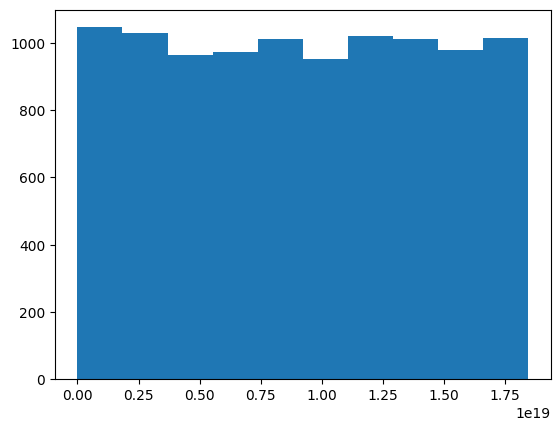

In [396]:
r = _canonical_combo_hash_v(np.arange(0,10000,1, dtype=np.uint64), np.arange(10000,0,-1, dtype=np.uint64))
_ = plt.hist(r)
f"{2**64:.5E}", f"{max(r):.5E}"

#### LMDB reading + sketch building

In [397]:
def _iter_reads_lmdb(
    lmdb_path: Path,
    limit: int | None = None,
):
    """Yield (read_id_0based, minimizer_ids, positions) from a rust-mdbg reads LMDB.

    Keys are 1-based ASCII-decimal read indices (e.g. b'1', b'42'); values are
    packed little-endian bytes.

    * New format (has_positions flag set): 12 bytes per minimizer —
      8-byte u64 hash followed by 4-byte u32 position (0-based, in original non-HPC read).
    * Old format: 8 bytes per minimizer (u64 hash only); yields None for positions.

    Yields in ascending numeric order so that read pairs (odd/even 1-based IDs) are adjacent.
    """
    if _lmdb is None:
        raise RuntimeError("lmdb package required; install with: pip install lmdb")
    env = _lmdb.open(
        str(lmdb_path), readonly=True, lock=False,
        max_dbs=_READS_LMDB_MAX_DBS, map_size=_READS_LMDB_MAP_SIZE,
    )
    reads_db = env.open_db(b"reads")
    try:
        meta_db = env.open_db(b"meta")
    except Exception:
        meta_db = None
    try:
        with env.begin() as txn:
            has_positions = (
                meta_db is not None
                and txn.get(b"has_positions", db=meta_db) == b""
            )

            all_keys: list[bytes] = []
            cur = txn.cursor(db=reads_db)
            for key in cur.iternext(keys=True, values=False):
                try:
                    int(key)
                    all_keys.append(key)
                except (ValueError, UnicodeDecodeError):
                    continue
            all_keys.sort(key=lambda k: int(k))

            count = 0
            for key in all_keys:
                if limit is not None and count >= limit:
                    break
                val = txn.get(key, db=reads_db)
                if val is None:
                    continue
                read_id = int(key) - 1  # 1-based → 0-based
                if has_positions:
                    n = len(val) // 12
                    if n:
                        raw = np.frombuffer(val, dtype=np.uint8).reshape(n, 12)
                        mids = np.frombuffer(raw[:, :8].tobytes(), dtype="<u8").copy()
                        pos = np.frombuffer(raw[:, 8:12].tobytes(), dtype="<u4").copy()
                    else:
                        mids = np.empty(0, dtype=np.uint64)
                        pos = np.empty(0, dtype=np.uint32)
                    yield read_id, mids, pos
                else:
                    n = len(val) // 8
                    mids = (
                        np.frombuffer(val, dtype="<u8").copy()
                        if n else np.empty(0, dtype=np.uint64)
                    )
                    yield read_id, mids, None
                count += 1
    finally:
        env.close()


def build_pe_combo_sketch(
    lmdb_path: Path,
    density: float,
    out_lmdb: Path | None = None,
    limit: int | None = None,
    max_distance: float | None = None,
) -> CombSketchIndex:
    """Build a cross-pair (R1 × R2) combination minimizer sketch.

    For each interleaved read pair, computes all (R1_minimizer, R2_minimizer)
    Cartesian-product pairs from the raw minimizer IDs and retains hashes
    ≤ _UINT64_MAX × density.

    Args:
        max_distance: When set, only combine R1 × R2 minimizer pairs whose
            positions are within this many bp of each other along their
            respective reads.  R1 is sequenced from the left end of the insert;
            R2 is the reverse complement sequenced from the right end, so
            position-from-start-of-R2 mirrors position-from-start-of-R1.
            Requires the LMDB to have been built with position storage (new
            12-byte-per-minimizer format); silently ignored otherwise.
    """
    threshold = np.uint64(int(_UINT64_MAX * density))
    logging.getLogger(__name__).info(
        "PE combo thinning: threshold=%d density=%.4f", int(threshold), density
    )
    index = CombSketchIndex(lmdb_path=out_lmdb)
    r1_mids: np.ndarray | None = None
    r1_pos: np.ndarray | None = None
    pairs_done = 0
    with Progress(*_PROGRESS_COLUMNS) as progress:
        task = progress.add_task("PE combo sketch", total=None)
        for read_id, mids, pos in _iter_reads_lmdb(lmdb_path, limit=limit):
            if read_id % 2 == 0:
                # R1: sequenced from the left end of the insert (forward strand)
                r1_mids = mids
                r1_pos = pos.astype(np.int64) if pos is not None else None
            elif r1_mids is not None:
                # R2: reverse-complement sequenced from the right end of the insert.
                # pos[j] is the 0-based position in R2 from the start of R2 (right end of insert),
                # so comparing pos[j] to r1_pos[i] tests that both minimizers lie the same
                # distance from their respective read starts.
                r2_mids = mids
                if len(r1_mids) > 0 and len(r2_mids) > 0:
                    # Full Cartesian product
                    r1_rep = np.repeat(r1_mids, len(r2_mids))
                    r2_tile = np.tile(r2_mids, len(r1_mids))
                    hashes = _canonical_combo_hash_v(r1_rep, r2_tile)
                    mask = hashes <= threshold
                    # Optional position filter
                    if max_distance is not None and r1_pos is not None and pos is not None:
                        r2_pos = pos.astype(np.int64)
                        pos_r1 = np.repeat(r1_pos, len(r2_mids))
                        pos_r2 = np.tile(r2_pos, len(r1_mids))
                        mask &= np.abs(pos_r1 - pos_r2) <= int(max_distance)
                    index._bulk_add(hashes[mask])
                r1_mids = None
                r1_pos = None
                pairs_done += 1
                if pairs_done % 100 == 0:
                    progress.update(task, completed=pairs_done)
        progress.update(task, completed=pairs_done)
    return index


def build_intra_combo_sketch(
    lmdb_path: Path,
    density: float,
    out_lmdb: Path | None = None,
    limit: int | None = None,
) -> CombSketchIndex:
    """Build a within-read combination minimizer sketch.

    For each read, computes all C(n, 2) pairs of raw minimizer IDs and retains
    hashes ≤ _UINT64_MAX × density.
    """
    threshold = np.uint64(int(_UINT64_MAX * density))
    logging.getLogger(__name__).info(
        "Intra combo thinning: threshold=%d density=%.4f", int(threshold), density
    )
    index = CombSketchIndex(lmdb_path=out_lmdb)
    reads_done = 0
    with Progress(*_PROGRESS_COLUMNS) as progress:
        task = progress.add_task("Intra combo sketch", total=None)
        for _, mids, _pos in _iter_reads_lmdb(lmdb_path, limit=limit):
            n = len(mids)
            if n >= 2:
                i_idx, j_idx = np.triu_indices(n, k=1)
                hashes = _canonical_combo_hash_v(mids[i_idx], mids[j_idx])
                index._bulk_add(hashes[hashes <= threshold])
            reads_done += 1
            if reads_done % 100 == 0:
                progress.update(task, completed=reads_done)
        progress.update(task, completed=reads_done)
    return index

In [398]:
r1_kmers = np.array([1,2], dtype=np.uint64)
r2_kmers = np.array([3,4], dtype=np.uint64)
hashes = _canonical_combo_hash_v(
    np.repeat(r1_kmers, len(r2_kmers)),
    np.tile(r2_kmers, len(r1_kmers)),
)
hashes

array([ 4048727598324417001,  8196980753821780235, 15047954047655532813,
       14119491246550939236], dtype=uint64)

In [399]:
_canonical_combo_hash_v(
    np.array([1], dtype=np.uint64),
    np.array([3], dtype=np.uint64)
)

array([4048727598324417001], dtype=uint64)

In [400]:
_canonical_combo_hash_v(
    np.array([1], dtype=np.uint64),
    np.array([4], dtype=np.uint64)
)

array([8196980753821780235], dtype=uint64)

In [401]:
_canonical_combo_hash_v(
    np.array([2], dtype=np.uint64),
    np.array([3], dtype=np.uint64)
)

array([15047954047655532813], dtype=uint64)

In [402]:
_canonical_combo_hash_v(
    np.array([2], dtype=np.uint64),
    np.array([4], dtype=np.uint64)
)

array([14119491246550939236], dtype=uint64)

In [403]:
_canonical_combo_hash_v(
    np.array([4], dtype=np.uint64),
    np.array([2], dtype=np.uint64)
)

array([14119491246550939236], dtype=uint64)

#### Path utilities + path minimizer positions + build_path_combo_sketch

In [404]:
def _opp(orient: str) -> str:
    """Return the opposite orientation character."""
    return "-" if orient == "+" else "+"


def _next_orient(cur_idx: int, cur_orient: str, link: Link) -> str | None:
    """Return the orientation of the neighbour reachable via *link*, or None."""
    if cur_idx == link.from_idx and cur_orient == link.from_orient:
        return link.to_orient
    if cur_idx == link.to_idx and cur_orient == _opp(link.to_orient):
        return _opp(link.from_orient)
    return None


def _overlap_length(cigar: str) -> float:
    """Return the total length of a CIGAR string (returns 1.0 for '*')."""
    if cigar == "*":
        return 1.0
    lengths = _CIGAR_RE.findall(cigar)
    return float(sum(int(n) for n in lengths)) if lengths else 1.0




def _path_bp_length(
    graph: rx.PyGraph,
    path: list[tuple[int, bool]],
) -> int:
    """Compute the overlap-corrected base-pair length of a path.

    Sums segment lengths and subtracts the bp overlap (from GFA link CIGAR
    strings) between each pair of consecutive segments.  This avoids the
    double-counting that occurs when naively summing segment lengths along a
    path in a k-order minimizer-space de Bruijn graph, where consecutive nodes
    share k−1 minimizers and their corresponding DNA.
    """
    if not path:
        return 0
    bp = sum(graph[idx].length for idx, _ in path)
    for i in range(1, len(path)):
        prev_idx = path[i - 1][0]
        cur_idx = path[i][0]
        edges = graph.get_all_edge_data(prev_idx, cur_idx)
        if edges:
            bp -= int(_overlap_length(edges[0].overlap))
    return bp

def _reverse_complement(seq: str) -> str:
    """Return the reverse complement of a DNA sequence."""
    return seq.translate(_RC_TABLE)[::-1]


def _compute_path_minimizer_positions(
    path: list[tuple[int, bool]],
    path_min_seq: np.ndarray,
    graph: rx.PyGraph,
    min_table: dict[int, str],
    l: int,
) -> np.ndarray | None:
    """Compute exact bp positions for every minimizer in a path.

    Reconstructs the full bp sequence by concatenating GFA segment sequences
    (with overlap correction), scans for each l-mer, and returns a position
    array. Returns None if any minimizer cannot be located.
    """
    lmer_to_hash: dict[str, int] = {}
    for h_raw in path_min_seq.tolist():
        h = int(h_raw)
        lmer = min_table.get(h)
        if lmer is None:
            return None
        lmer_to_hash[lmer] = h
        lmer_to_hash[_reverse_complement(lmer)] = h

    seq_parts: list[str] = []
    for seg_i, (node_idx, is_forward) in enumerate(path):
        seg = graph[node_idx]
        if not seg.sequence or seg.sequence == "*":
            return None
        seq = seg.sequence if is_forward else _reverse_complement(seg.sequence)
        if seg_i == 0:
            seq_parts.append(seq)
        else:
            prev_idx = path[seg_i - 1][0]
            overlap_bp = 0
            edges = graph.get_all_edge_data(prev_idx, node_idx)
            if edges:
                overlap_bp = int(_overlap_length(edges[0].overlap))
            seq_parts.append(seq[overlap_bp:])

    full_seq = "".join(seq_parts)

    pos_by_hash: dict[int, list[int]] = {}
    for p in range(len(full_seq) - l + 1):
        lmer = full_seq[p: p + l]
        h = lmer_to_hash.get(lmer)
        if h is not None:
            pos_by_hash.setdefault(h, []).append(p)

    positions = np.zeros(len(path_min_seq), dtype=np.int64)
    last_pos = -1
    for i, h_raw in enumerate(path_min_seq.tolist()):
        h = int(h_raw)
        candidates = [p for p in pos_by_hash.get(h, []) if p > last_pos]
        if not candidates:
            return None
        positions[i] = candidates[0]
        last_pos = candidates[0]

    return positions


def build_path_combo_sketch(
    path_min_seq: np.ndarray,
    bin_distances: list[float],
    density: float,
    bp_scale: float,
    k: int = 7,
    use_exact_distances: bool = False,
    path: list[tuple[int, bool]] | None = None,
    graph: rx.PyGraph | None = None,
    min_table: dict[int, str] | None = None,
    l: int = 12,
) -> list[CombSketchIndex]:
    """Build a distance-binned combination minimizer sketch for a path.

    For every pair of minimizers (i, j) whose bp distance falls within
    ``[bin_distances[0], bin_distances[-1]]``, computes a combination hash and
    adds it to the appropriate distance bin if it survives thinning.

    Returns a list of CombSketchIndex objects, one per bin.
    """
    if len(bin_distances) < 2:
        raise ValueError("bin_distances must have at least 2 values")

    n_bins = len(bin_distances) - 1
    bin_arr = np.array(bin_distances, dtype=np.float64)

    exact_positions: np.ndarray | None = None
    if use_exact_distances and path is not None and graph is not None and min_table is not None:
        exact_positions = _compute_path_minimizer_positions(path, path_min_seq, graph, min_table, l)

    min_gap = max(1, int(bin_distances[0] / bp_scale))
    max_gap = int(bin_distances[-1] / bp_scale) + 1
    threshold = np.uint64(int(_UINT64_MAX * density))

    path_kmer_seq = _compute_kmer_hashes(path_min_seq, k) if k>0 else path_min_seq
    sketches: list[CombSketchIndex] = [CombSketchIndex() for _ in range(n_bins)]
    n = len(path_kmer_seq)

    if exact_positions is not None:
        exact_pos_k = exact_positions[:n]
        hash_to_bin_ex: dict[int, int] = {}
        for i in range(n):
            pos_i = exact_pos_k[i]
            j_lo = int(np.searchsorted(exact_pos_k, pos_i + bin_distances[0], side="left"))
            j_hi = int(np.searchsorted(exact_pos_k, pos_i + bin_distances[-1], side="right")) - 1
            j_lo = max(j_lo, i + 1)
            if j_lo > j_hi:
                continue
            j_range = np.arange(j_lo, j_hi + 1, dtype=np.intp)
            a_arr = np.full(len(j_range), path_kmer_seq[i], dtype=np.uint64)
            hashes = _canonical_combo_hash_v(a_arr, path_kmer_seq[j_range])
            keep = hashes <= threshold
            if not np.any(keep):
                continue
            kept_hashes = hashes[keep]
            kept_dists = (exact_pos_k[j_range[keep]] - pos_i).astype(np.float64)
            bin_indices = np.searchsorted(bin_arr, kept_dists, side="right") - 1
            for h_val, b_idx in zip(kept_hashes.tolist(), bin_indices.tolist()):
                if 0 <= b_idx < n_bins:
                    if h_val in hash_to_bin_ex:
                        if hash_to_bin_ex[h_val] != b_idx:
                            hash_to_bin_ex[h_val] = -1
                    else:
                        hash_to_bin_ex[h_val] = b_idx
        for h_val, b_idx in hash_to_bin_ex.items():
            if b_idx >= 0:
                sketches[b_idx].increment(h_val)
    else:
        hash_to_bin: dict[int, int] = {}
        for i in range(n):
            j_lo = i + min_gap
            j_hi = min(i + max_gap, n - 1)
            if j_lo > n - 1:
                break
            j_range = np.arange(j_lo, j_hi + 1, dtype=np.intp)
            a_arr = np.full(len(j_range), path_kmer_seq[i], dtype=np.uint64)
            hashes = _canonical_combo_hash_v(a_arr, path_kmer_seq[j_range])
            keep = hashes <= threshold
            if not np.any(keep):
                continue
            kept_hashes = hashes[keep]
            kept_dists = (j_range[keep] - i).astype(np.float64) * bp_scale
            bin_indices = np.searchsorted(bin_arr, kept_dists, side="right") - 1
            for h_val, b_idx in zip(kept_hashes.tolist(), bin_indices.tolist()):
                if 0 <= b_idx < n_bins:
                    if h_val in hash_to_bin:
                        if hash_to_bin[h_val] != b_idx:
                            hash_to_bin[h_val] = -1
                    else:
                        hash_to_bin[h_val] = b_idx
        for h_val, b_idx in hash_to_bin.items():
            if b_idx >= 0:
                sketches[b_idx].increment(h_val)

    return sketches

#### Path sampling

In [405]:
def leaf_nodes(graph: rx.PyGraph) -> list[int]:
    """Return node indices whose degree is exactly 1."""
    return [idx for idx in graph.node_indices() if graph.degree(idx) == 1]


def large_component_nodes(
    graph: rx.PyGraph,
    min_proportion: float,
) -> tuple[set[int], list[set[int]]]:
    """Return node indices in the largest components covering *min_proportion*.

    Components are sorted by total base-pair span and added largest-first until
    the cumulative node count reaches ``min_proportion * graph.num_nodes()``.
    Pass 0.0 to select all components.
    """
    components = sorted(
        rx.connected_components(graph),
        key=lambda c: sum(graph[idx].length for idx in c),
        reverse=True,
    )
    if min_proportion <= 0.0:
        return set().union(*components) if components else set(), components
    threshold = math.ceil(min_proportion * graph.num_nodes())
    selected: set[int] = set()
    chosen: list[set[int]] = []
    for comp in components:
        selected |= comp
        chosen.append(comp)
        if len(selected) >= threshold:
            break
    return selected, chosen


def _pick_by_kmer(graph: rx.PyGraph, cands: list[int], _edges: dict) -> int:
    """Choose next node weighted by k-mer count."""
    weights = [float(graph[n].kmer_count or 1) for n in cands]
    return random.choices(cands, weights=weights)[0]


def _pick_by_overlap(_graph: rx.PyGraph, cands: list[int], edges: dict) -> int:
    """Choose next node weighted by overlap length."""
    weights = [_overlap_length(edges[n].overlap) for n in cands]
    return random.choices(cands, weights=weights)[0]


def _pick_uniformly(_graph: rx.PyGraph, cands: list[int], _edges: dict) -> int:
    """Choose next node uniformly at random."""
    return random.choice(cands)


_PICK_FN = {
    "kmer":       _pick_by_kmer,
    "overlap":    _pick_by_overlap,
    "unweighted": _pick_uniformly,
}


def _random_simple_path(
    graph: rx.PyGraph,
    start_nodes: list[int],
    weight_mode: str,
) -> list[tuple[int, bool]]:
    """Sample a random simple path by greedy random walk.

    Starts from a randomly chosen node in *start_nodes*, extends via
    orientation-valid unvisited neighbours, tracking GFA bidirected-edge
    semantics. Returns a list of ``(node_idx, is_forward)`` pairs.
    """
    pick = _PICK_FN.get(weight_mode, _pick_uniformly)
    start = random.choice(start_nodes)

    adj_start = graph.adj(start)
    if adj_start:
        first_link: Link = next(iter(adj_start.values()))
        start_orient = (
            first_link.from_orient if first_link.from_idx == start
            else _opp(first_link.to_orient)
        )
    else:
        start_orient = "+"

    path: list[tuple[int, bool]] = [(start, start_orient == "+")]
    visited: set[int] = {start}

    while True:
        cur_idx, cur_fwd = path[-1]
        cur_orient = "+" if cur_fwd else "-"

        valid: dict[int, tuple[Link, str]] = {}
        fallback: dict[int, Link] = {}
        for nbr_idx, link in graph.adj(cur_idx).items():
            if nbr_idx in visited:
                continue
            nbr_orient = _next_orient(cur_idx, cur_orient, link)
            if nbr_orient is not None:
                valid[nbr_idx] = (link, nbr_orient)
            else:
                fallback[nbr_idx] = link

        if valid:
            chosen = pick(graph, list(valid.keys()), {k: v[0] for k, v in valid.items()})
            _, chosen_orient = valid[chosen]
        elif fallback:
            chosen = pick(graph, list(fallback.keys()), fallback)
            chosen_orient = "+"
        else:
            break

        path.append((chosen, chosen_orient == "+"))
        visited.add(chosen)

    return path


def _iter_sampled_paths(
    graph: rx.PyGraph,
    n_samples: int,
    weight_mode: str = "kmer",
    eligible_nodes: set[int] | None = None,
):
    """Yield ``(path, bp_length)`` for *n_samples* random simple paths."""
    leaves = leaf_nodes(graph)
    if eligible_nodes is not None:
        leaves = [n for n in leaves if n in eligible_nodes]
    if leaves:
        start_nodes = leaves
    else:
        fallback = (
            list(eligible_nodes) if eligible_nodes is not None
            else list(graph.node_indices())
        )
        logging.getLogger(__name__).warning(
            "No eligible leaf nodes (all degrees > 1); "
            "using %d eligible nodes as start candidates.", len(fallback)
        )
        start_nodes = fallback

    with Progress(*_PROGRESS_COLUMNS) as progress:
        task = progress.add_task("Sampling paths", total=n_samples)
        for _ in range(n_samples):
            path = _random_simple_path(graph, start_nodes, weight_mode)
            bp = _path_bp_length(graph, path)
            yield path, bp
            progress.advance(task)


def sample_paths(
    graph: rx.PyGraph,
    n_samples: int,
    weight_mode: str = "kmer",
    eligible_nodes: set[int] | None = None,
) -> list[tuple[list[tuple[int, bool]], int]]:
    """Sample random simple paths and return them with their bp lengths."""
    return list(_iter_sampled_paths(graph, n_samples, weight_mode, eligible_nodes))


def sample_path_lengths(
    graph: rx.PyGraph,
    n_samples: int,
    weight_mode: str = "kmer",
    eligible_nodes: set[int] | None = None,
) -> list[int]:
    """Sample random simple paths and return their bp lengths."""
    return [bp for _, bp in _iter_sampled_paths(graph, n_samples, weight_mode, eligible_nodes)]


def longest_simple_path(graph: rx.PyGraph) -> list[int]:
    """Return a longest simple path in the graph (exhaustive — slow for large graphs)."""
    result = rx.longest_simple_path(graph)
    return list(result) if result is not None else []

#### Build_top_path_combo_sketches

In [406]:
def build_top_path_combo_sketches(
    graph: rx.PyGraph,
    lmdb_path: Path | None,
    bin_distances: list[float],
    density: float,
    n_paths: int = 50,
    top_paths: list[tuple[list[tuple[int, bool]], int]] | None = None,
    use_exact_distances: bool = False,
    min_table: dict[int, str] | None = None,
    l: int = 12,
    bp_scale: float | None = None,
    seqs_prefix: Path | None = None,
) -> tuple[list[list[CombSketchIndex]], float]:
    """Build distance-binned combination minimizer sketches for the top paths.

    For each path in *top_paths* (up to *n_paths*), reconstructs the minimizer
    sequence from rust-mdbg LZ4 sequences files and builds per-bin sketches via
    :func:`build_path_combo_sketch`.  Combo hashes are formed directly from
    pairs of raw minimizer IDs without combining neighbouring minimizers.

    Returns ``(list_of_per_path_sketch_lists, bp_scale_used)``.
    """
    if not top_paths:
        logging.getLogger(__name__).warning("No top paths provided; skipping.")
        return [], 1.0

    node_min_seqs: dict[int, np.ndarray] = {}
    k_val = 1
    if seqs_prefix is not None:
        node_min_seqs, k_val = _load_node_minimizer_seqs(seqs_prefix)
        if not node_min_seqs:
            logging.getLogger(__name__).warning(
                "Sequences files empty or unreadable; falling back to node-index proxy."
            )

    selected = top_paths[:n_paths]

    if bp_scale is None:
        total_bp = 0
        total_min = 0
        for path, bp_len in selected:
            total_bp += bp_len
            if node_min_seqs:
                for seg_i, (node_idx, _is_fwd) in enumerate(path):
                    mids = node_min_seqs.get(int(graph[node_idx].name))
                    if mids is not None:
                        if seg_i == 0:
                            total_min += len(mids)
                        else:
                            total_min += max(1, len(mids) - (k_val - 1))
                    else:
                        total_min += 1
            else:
                total_min += len(path)
        bp_scale = total_bp / max(total_min, 1)
        logging.getLogger(__name__).info(
            "Estimated bp_scale=%.2f from %d top path(s)", bp_scale, len(selected)
        )

    path_sketch_lists: list[list[CombSketchIndex]] = []

    with Progress(*_PROGRESS_COLUMNS) as progress:
        task = progress.add_task("Building path combo sketches", total=len(selected))
        for path, _bp_len in selected:
            if node_min_seqs:
                min_ids: list[int] = []
                valid = True
                for seg_i, (node_idx, is_fwd) in enumerate(path):
                    mids = node_min_seqs.get(int(graph[node_idx].name))
                    if mids is None or len(mids) == 0:
                        valid = False
                        break
                    node_mids: np.ndarray = mids if is_fwd else mids[::-1]
                    if seg_i == 0:
                        min_ids.extend(node_mids.tolist())
                    else:
                        overlap = k_val - 1
                        new_mids = node_mids[overlap:] if len(node_mids) > overlap else node_mids[-1:]
                        min_ids.extend(new_mids.tolist())
                if not valid or len(min_ids) < 2:
                    progress.advance(task)
                    continue
                path_min_seq = np.array(min_ids, dtype=np.uint64)
            else:
                path_min_seq = np.array([node_idx for node_idx, _ in path], dtype=np.uint64)
                if len(path_min_seq) < 2:
                    progress.advance(task)
                    continue

            sketches = build_path_combo_sketch(
                path_min_seq=path_min_seq,
                bin_distances=bin_distances,
                density=density,
                bp_scale=bp_scale,
                k=1,
                use_exact_distances=use_exact_distances,
                path=path if use_exact_distances else None,
                graph=graph if use_exact_distances else None,
                min_table=min_table if use_exact_distances else None,
                l=l,
            )
            path_sketch_lists.append(sketches)
            progress.advance(task)

    logging.getLogger(__name__).info(
        "Built path combo sketches for %d/%d paths",
        len(path_sketch_lists), len(selected),
    )
    return path_sketch_lists, bp_scale

#### Fragment length estimation

In [701]:
def aggregate_path_bin_sketches(
    path_sketches: list[list[CombSketchIndex]],
    max_pool_hashes: int = 500_000,
) -> list[set[int]]:
    """Union per-path per-bin sketches into one set per bin.

    Kept for debugging / comparison with the per-path approach.
    """
    if not path_sketches:
        return []
    n_bins = len(path_sketches[0])
    pooled: list[set[int]] = [set() for _ in range(n_bins)]

    with Progress(*_PROGRESS_COLUMNS) as progress:
        task = progress.add_task("Pooling path sketches", total=len(path_sketches))
        for sketch_list in path_sketches:
            for b, sketch in enumerate(sketch_list):
                if b >= n_bins:
                    break
                pooled[b].update(sketch._buf.keys())
            progress.advance(task)

    for b in range(n_bins):
        if len(pooled[b]) > max_pool_hashes:
            pooled[b] = set(random.sample(list(pooled[b]), max_pool_hashes))

    return pooled


def _sketch_keys(sketch: CombSketchIndex) -> set[int]:
    """Return all unique combination-hash keys stored in *sketch*."""
    if sketch._env is None:
        return set(sketch._buf.keys())
    sketch._flush()
    keys: set[int] = set()
    with sketch._env.begin() as txn:
        for key, _ in txn.cursor(db=sketch._lmdb_db):
            keys.add(struct.unpack("<Q", key)[0])
    return keys


def compute_containment_rates(
    pe_sketch: CombSketchIndex,
    path_bin_sets: list[set[int]],
) -> tuple[np.ndarray, np.ndarray, int]:
    """Compute per-bin containment of path hashes in the PE sketch (pooled version).

    For each distance bin b::

        c_obs[b]   = |pe_sketch ∩ path_bin_sets[b]| / |path_bin_sets[b]|
    """
    pe_keys = _sketch_keys(pe_sketch)
    n_pe = len(pe_keys)

    n_bins = len(path_bin_sets)
    c_obs = np.full(n_bins, np.nan)

    for b, path_set in enumerate(path_bin_sets):
        if not path_set:
            continue
        n_path = len(path_set)
        c_obs[b] = len(pe_keys & path_set) / n_path

    return c_obs, n_pe


def compute_per_path_containment_rates(
    pe_sketch: CombSketchIndex,
    path_bin_sketches: list[list[CombSketchIndex]],
) -> tuple[np.ndarray, np.ndarray, np.ndarray, int]:
    """Compute per-path per-bin containment rates.

    Returns one containment rate per (path, bin) pair instead of pooling all
    paths together.  This preserves per-path variance and lets the inference
    model weight each path proportionally to how many hashes it contributes
    in each bin.

    Args:
        pe_sketch:          Cross-pair (R1×R2) combination minimizer sketch.
        path_bin_sketches:  ``[n_paths][n_bins]`` per-path per-bin sketches
                            from :func:`build_top_path_combo_sketches`.

    Returns:
        c_obs:    float32 array shape ``[n_paths, n_bins]`` — fraction of each
                  path-bin's hashes found in *pe_sketch* (NaN when the bin is
                  empty for that path).
        n_hashes: float32 array shape ``[n_paths, n_bins]`` — number of unique
                  hashes in each path-bin sketch.
        n_pe:     Total unique hashes in *pe_sketch*.
    """
    if not path_bin_sketches:
        return (
            np.empty((0, 0), dtype=np.float32),
            np.empty((0, 0), dtype=np.float32),
            np.empty((0, 0), dtype=np.float32),
            0,
        )

    pe_keys = _sketch_keys(pe_sketch)
    n_pe = len(pe_keys)

    n_paths = len(path_bin_sketches)
    n_bins = len(path_bin_sketches[0])
    c_obs    = np.full((n_paths, n_bins), np.nan, dtype=np.float32)
    n_hashes = np.zeros((n_paths, n_bins), dtype=np.float32)

    for p, sketch_list in enumerate(path_bin_sketches):
        for b, sketch in enumerate(sketch_list):
            path_set = _sketch_keys(sketch)
            n = len(path_set)
            n_hashes[p, b] = n
            if n == 0:
                continue
            c_obs[p, b] = len(pe_keys & path_set) / n

    return c_obs, n_hashes, n_pe


def _fragment_length_pyro_model(
    c_adjusted,
    bin_lo,
    bin_hi,
    n_path_hashes,
    observed_mask,
) -> None:
    """Pyro generative model for fragment length from per-path containment rates.

    The parameters ``mu_log``, ``sigma_log``, and ``rho`` are shared across all
    paths.  Each (path, bin) pair whose hash count passes the minimum threshold
    contributes one independent Normal observation.

    Priors::

        mu_log    ~ Normal(log(8000), 1.0)
        sigma_log ~ HalfNormal(0.5)
        rho       ~ Beta(2, 20)

    Likelihood per active (path, bin) pair::

        p[b]            = LogNormal(mu_log, sigma_log).CDF(bin_hi[b])
                        - LogNormal(mu_log, sigma_log).CDF(bin_lo[b])
        expected[b]     = p[b] * (1 - rho) + rho
        sigma_obs[p, b] = sqrt(expected[b] * (1 - expected[b]) / n_hashes[p, b])
        obs[p, b]       ~ Normal(expected[b], sigma_obs[p, b])

    Args:
        c_adjusted:    Tensor ``[n_paths, n_bins]`` — noise-subtracted containment.
        bin_lo:        Tensor ``[n_bins]`` — lower bin edges in bp.
        bin_hi:        Tensor ``[n_bins]`` — upper bin edges in bp.
        n_path_hashes: Tensor ``[n_paths, n_bins]`` — hash counts per path-bin.
        observed_mask: Bool tensor ``[n_paths, n_bins]`` — active path-bin pairs.
    """
    mu_log = _pyro.sample(
        "mu_log",
        _pyro_dist.LogNormal(_torch.tensor(np.log(1000.0)), _torch.tensor(20.)),
    )
    sigma_log = _pyro.sample(
        "sigma_log", _pyro_dist.HalfNormal(_torch.tensor(0.5))
    )
    rho = _pyro.sample(
        "rho", _pyro_dist.Beta(_torch.tensor(1.0), _torch.tensor(20.0))
    )
    # rho = _pyro.sample(
    #     "rho", _pyro_dist.Uniform(_torch.tensor(0.0), _torch.tensor(1.0))
    # )
    norm = _pyro.sample(
        "norm", _pyro_dist.Beta(_torch.tensor(2.0), _torch.tensor(2.0))
    )
    
    lognormal = _torch.distributions.LogNormal(_torch.log(mu_log), sigma_log)
    # p shape: [n_bins]
    p = (lognormal.cdf(bin_hi) - lognormal.cdf(bin_lo))
    # expected shape: [n_bins], broadcast to [n_paths, n_bins] via unsqueeze
    expected = p * norm + rho

    # sigma_obs shape: [n_paths, n_bins]
    # sigma_obs = (
    #     expected * (1.0 - expected) / n_path_hashes.clamp(min=1.0)
    # ).sqrt().clamp(min=1e-6)
    # sigma_obs = _pyro.sample(
    #     "sigma_obs", _pyro_dist.HalfNormal(_torch.tensor(0.5))
    # )
    sigma_obs = 0.05

    n_paths, n_bins = c_adjusted.shape
    with _pyro.plate("paths", n_paths, dim=-2):
        with _pyro.plate("bins", n_bins, dim=-1):
            with _pyro.poutine.mask(mask=observed_mask):
                _pyro.sample(
                    "obs",
                    _pyro_dist.Normal(expected.unsqueeze(0), sigma_obs),
                    obs=c_adjusted,
                )


def estimate_fragment_length(
    pe_sketch: CombSketchIndex,
    path_bin_sketches: list[list[CombSketchIndex]],
    bin_distances: list[float],
    read_length: int = 150,
    min_path_hashes_per_bin: int = 50,
    inference: str = "nuts",
    num_samples: int = 500,
    num_warmup: int = 200,
) -> FragmentLengthEstimate:
    """Estimate the fragment length distribution from per-path containment rates.

    For each path in *path_bin_sketches*, computes a containment rate per
    distance bin relative to the PE sketch, then fits a log-normal distribution
    over those ``n_paths × n_bins`` independent observations via Bayesian
    inference (NUTS or ADVI).

    Each path-bin pair is weighted by its binomial noise (fewer hashes ⟹
    wider normal likelihood), so paths with sparse coverage in a bin
    automatically contribute less to the posterior.
    """
    if _pyro is None or _torch is None:
        raise RuntimeError(
            "pyro-ppl and torch are required for insert size estimation."
        )

    c_obs, n_hashes, n_pe = compute_per_path_containment_rates(
        pe_sketch, path_bin_sketches,
    )
    logging.getLogger(__name__).info(
        "PE sketch: %d unique hashes; per-path containment rates (mean per bin): %s",
        n_pe, np.round(np.nanmean(c_obs, axis=0), 4),
    )

    n_bins = len(bin_distances) - 1
    bin_lo = np.array(bin_distances[:-1], dtype=np.float32)
    bin_hi = np.array(bin_distances[1:],  dtype=np.float32)

    # c_adjusted: [n_paths, n_bins], clipped to [0, 1]
    c_adjusted = np.clip(
        np.where(np.isnan(c_obs), 0.0, c_obs),
        0.0, 1.0,
    ).astype(np.float32)

    # A path-bin is "observed" only when it has enough hashes
    observed_mask = n_hashes >= min_path_hashes_per_bin  # [n_paths, n_bins]

    # n_bins_used: how many bins have at least one valid path observation
    n_bins_used = int(observed_mask.any(axis=0).sum())

    # Signal reliability: range of containment rates over valid path-bin pairs
    active_c = c_adjusted * observed_mask
    
    signal_reliable = True
    if len(active_c) > 1:
        c_range = float(active_c.max() - active_c.min())
        if c_range < 0.10:
            signal_reliable = False
            logging.getLogger(__name__).warning(
                "Containment rates are nearly flat (range=%.3f). "
                "Signal is weak — estimate dominated by prior.", c_range
            )

    if n_bins_used == 0:
        mu0 = math.log(8000.0)
        return FragmentLengthEstimate(
            mu_log=mu0, sigma_log=0.5,
            mu_log_ci=(mu0 - 1.0, mu0 + 1.0),
            sigma_log_ci=(0.0, 1.0),
            median=math.exp(mu0),
            mean=math.exp(mu0 + 0.5**2 / 2.0),
            n_bins_used=0, inference=inference, signal_reliable=False,
        )

    c_adj_t  = _torch.tensor(c_adjusted, dtype=_torch.float32)                  # [n_paths, n_bins]
    bin_lo_t = _torch.tensor(bin_lo,     dtype=_torch.float32).clamp(min=1.0)   # [n_bins]
    bin_hi_t = _torch.tensor(bin_hi,     dtype=_torch.float32).clamp(min=1.0)   # [n_bins]
    n_path_t = _torch.tensor(n_hashes,   dtype=_torch.float32)                  # [n_paths, n_bins]
    mask_t   = _torch.tensor(observed_mask, dtype=_torch.bool)                  # [n_paths, n_bins]
    model_args = (c_adj_t, bin_lo_t, bin_hi_t, n_path_t, mask_t)

    if inference == "nuts":
        _pyro.clear_param_store()
        # Initial values in constrained (natural) space for AutoNormal / init_to_value.
        # mu_log ~ LogNormal(log(1000), 20): start at the prior geometric mean (1000 bp).
        # sigma_log ~ HalfNormal(0.5): prior mean ≈ 0.4; start there.
        # rho ~ Beta(1, 20): prior mean = 1/21 ≈ 0.05; start at the prior mean.
        # norm ~ Beta(1, 1) = Uniform(0, 1): prior mean = 0.5; start there.
        initial_params = {
            "mu_log": _torch.tensor(np.log(1000.0)),
            "sigma_log": _torch.tensor(0.4),
            "rho": _torch.tensor(0.05),
            "norm": _torch.tensor(0.5),
        }
        
        kernel = NUTS(_fragment_length_pyro_model)
        mcmc = MCMC(kernel, num_samples=num_samples, warmup_steps=num_warmup, disable_progbar=False, initial_params=initial_params)
        mcmc.run(*model_args)
        samples = mcmc.get_samples()
        mu_log_samps    = samples["mu_log"].numpy()
        sigma_log_samps = samples["sigma_log"].numpy()
        rho_samps       = samples["rho"].numpy()
        norm_samps      = samples["norm"].numpy()
        # sigma_obs_samps = samples["sigma_obs"].numpy()

    elif inference == "advi":
        _pyro.clear_param_store()
        # Initial values in constrained (natural) space for AutoNormal / init_to_value.
        # mu_log ~ LogNormal(log(1000), 20): start at the prior geometric mean (1000 bp).
        # sigma_log ~ HalfNormal(0.5): prior mean ≈ 0.4; start there.
        # rho ~ Beta(1, 20): prior mean = 1/21 ≈ 0.05; start at the prior mean.
        # norm ~ Beta(1, 1) = Uniform(0, 1): prior mean = 0.5; start there.
        initial_params = {
            "mu_log": _torch.tensor(np.log(1000.0)),
            "sigma_log": _torch.tensor(0.4),
            "rho": _torch.tensor(0.05),
            "norm": _torch.tensor(0.5),
        }
        guide = AutoNormal(_fragment_length_pyro_model, init_loc_fn=_pyro.infer.autoguide.init_to_value(values=initial_params))
        optimizer = _PyroAdam({"lr": 0.01})
        svi_obj = SVI(_fragment_length_pyro_model, guide, optimizer, loss=Trace_ELBO())
        _advi_steps = 2000
        with Progress(*_PROGRESS_COLUMNS) as progress:
            task = progress.add_task("ADVI inference", total=_advi_steps)
            for step in range(_advi_steps):
                loss = svi_obj.step(*model_args)
                progress.advance(task)
        predictive = Predictive(
            _fragment_length_pyro_model, guide=guide,
            num_samples=num_samples, return_sites=["mu_log", "sigma_log", "rho", "norm"],  # , "sigma_obs"
        )
        post = predictive(*model_args)
        mu_log_samps    = post["mu_log"].squeeze().numpy()
        sigma_log_samps = post["sigma_log"].squeeze().numpy()
        rho_samps       = post["rho"].squeeze().numpy()
        norm_samps      = post["norm"].squeeze().numpy()
        # sigma_obs_samps = post["sigma_obs"].squeeze().numpy()
    else:
        raise ValueError(f"Unknown inference method {inference!r}; use 'nuts' or 'advi'")

    mu_log_mean    = float(np.mean(mu_log_samps))
    sigma_log_mean = float(np.mean(sigma_log_samps))
    mu_log_ci = (float(np.percentile(mu_log_samps, 2.5)),  float(np.percentile(mu_log_samps, 97.5)))
    sigma_log_ci = (float(np.percentile(sigma_log_samps, 2.5)), float(np.percentile(sigma_log_samps, 97.5)))
    rho_mean = float(np.mean(rho_samps))
    norm_mean = float(np.mean(norm_samps))
    sigma_obs_mean = 0.05  # float(np.mean(sigma_obs_samps))

    return FragmentLengthEstimate(
        mu_log=mu_log_mean, sigma_log=sigma_log_mean,
        mu_log_ci=mu_log_ci, sigma_log_ci=sigma_log_ci,
        rho=rho_mean, sigma_obs=sigma_obs_mean, 
        norm=norm_mean,
        median=mu_log_mean,
        mean=mu_log_mean + sigma_log_mean**2 / 2.0,
        n_bins_used=n_bins_used, inference=inference, signal_reliable=signal_reliable,
    )

def estimate_fragment_length_map(
    pe_sketch: CombSketchIndex,
    path_bin_sketches: list[list[CombSketchIndex]],
    bin_distances: list[float],
    min_path_hashes_per_bin: int = 50,
    num_steps: int = 2000,
    lr: float = 0.01,
) -> FragmentLengthMAP:
    """Find MAP parameter values for the fragment length model.

    Uses an :class:`AutoDelta` guide (one unconstrained parameter per latent
    site) with SVI to maximise the joint log-probability
    p(mu_log, sigma_log, rho, obs).  Returns a single optimal parameter set
    rather than a posterior distribution, making it faster than NUTS or ADVI
    while still respecting the prior.

    Args:
        pe_sketch:               Cross-pair (R1×R2) combination minimizer sketch.
        path_bin_sketches:       Per-path per-bin sketches from
                                 :func:`build_top_path_combo_sketches`.
        bin_distances:           Sorted bp breakpoints (length = n_bins + 1).
        min_path_hashes_per_bin: Minimum hashes in a path-bin to include it.
        num_steps:               Number of SVI optimisation steps.
        lr:                      Adam learning rate.

    Returns:
        :class:`FragmentLengthMAP` with the MAP values of ``mu_log``,
        ``sigma_log``, and ``rho``, plus derived ``median`` and ``mean`` bp.
    """
    if _pyro is None or _torch is None:
        raise RuntimeError(
            "pyro-ppl and torch are required for insert size MAP estimation."
        )

    c_obs, n_hashes, n_pe = compute_per_path_containment_rates(
        pe_sketch, path_bin_sketches,
    )
    logging.getLogger(__name__).info(
        "PE sketch: %d unique hashes; per-path containment rates (mean per bin): %s",
        n_pe, np.round(np.nanmean(c_obs, axis=0), 4),
    )

    n_bins = len(bin_distances) - 1
    bin_lo = np.array(bin_distances[:-1], dtype=np.float32)
    bin_hi = np.array(bin_distances[1:],  dtype=np.float32)

    c_adjusted = np.clip(
        np.where(np.isnan(c_obs), 0.0, c_obs),
        0.0, 1.0,
    ).astype(np.float32)

    observed_mask = n_hashes >= min_path_hashes_per_bin  # [n_paths, n_bins]
    n_bins_used = int(observed_mask.any(axis=0).sum())

    active_c = c_adjusted * observed_mask
    signal_reliable = True
    if len(active_c) > 1:
        c_range = float(active_c.max() - active_c.min())
        if c_range < 0.10:
            signal_reliable = False
            logging.getLogger(__name__).warning(
                "Containment rates are nearly flat (range=%.3f). "
                "Signal is weak — MAP estimate dominated by prior.", c_range
            )

    if n_bins_used == 0:
        mu0 = math.log(8000.0)
        return FragmentLengthMAP(
            mu_log=mu0, sigma_log=0.5, rho=0.1,
            median=math.exp(mu0),
            mean=math.exp(mu0 + 0.5**2 / 2.0),
            n_bins_used=0, signal_reliable=False,
        )

    c_adj_t  = _torch.tensor(c_adjusted,    dtype=_torch.float32)   # [n_paths, n_bins]
    bin_lo_t = _torch.tensor(bin_lo,        dtype=_torch.float32)   # [n_bins]
    bin_hi_t = _torch.tensor(bin_hi,        dtype=_torch.float32)   # [n_bins]
    n_path_t = _torch.tensor(n_hashes,      dtype=_torch.float32)   # [n_paths, n_bins]
    mask_t   = _torch.tensor(observed_mask, dtype=_torch.bool)      # [n_paths, n_bins]
    model_args = (c_adj_t, bin_lo_t, bin_hi_t, n_path_t, mask_t)

    # AutoDelta places a Dirac delta at an unconstrained parameter for each
    # latent site and optimises via SVI — equivalent to MAP estimation.
    _pyro.clear_param_store()
    guide = AutoDelta(_fragment_length_pyro_model)
    svi = SVI(_fragment_length_pyro_model, guide, _PyroAdam({"lr": lr}), loss=Trace_ELBO())

    loss_final = float("nan")
    with Progress(*_PROGRESS_COLUMNS) as progress:
        task = progress.add_task("MAP optimisation", total=num_steps)
        for _ in range(num_steps):
            loss_final = svi.step(*model_args)
            progress.advance(task)

    # Predictive with 1 sample returns the MAP point (all samples are identical
    # for a Dirac-delta guide).
    map_samples = Predictive(
        _fragment_length_pyro_model, guide=guide,
        num_samples=1, return_sites=["mu_log", "sigma_log", "rho"],
    )(*model_args)

    mu_log_map    = float(map_samples["mu_log"].squeeze())
    sigma_log_map = float(map_samples["sigma_log"].squeeze())
    rho_map       = float(map_samples["rho"].squeeze())

    return FragmentLengthMAP(
        mu_log=mu_log_map,
        sigma_log=sigma_log_map,
        rho=rho_map,
        median=math.exp(mu_log_map),
        mean=math.exp(mu_log_map + sigma_log_map**2 / 2.0),
        n_bins_used=n_bins_used,
        signal_reliable=signal_reliable,
        loss_final=loss_final,
    )

#### Summary statistics

In [408]:
def _compute_summary(
    graph: rx.PyGraph,
    path_lengths: list[int] | None,
    weight_mode: str = "kmer",
    pair_distances: list[int] | None = None,
) -> dict[str, object]:
    """Compute a summary of graph properties as a dict."""
    n_nodes = graph.num_nodes()
    n_edges = graph.num_edges()
    result: dict[str, object] = {"nodes": n_nodes, "edges": n_edges}

    if n_nodes == 0:
        return result

    components = rx.connected_components(graph)
    component_sizes = sorted((len(c) for c in components), reverse=True)
    n_comp = len(component_sizes)
    comp_mean = sum(component_sizes) / n_comp
    comp_variance = sum((x - comp_mean) ** 2 for x in component_sizes) / n_comp
    mid = n_comp // 2
    comp_median: float = (
        component_sizes[mid]
        if n_comp % 2 == 1
        else (component_sizes[mid - 1] + component_sizes[mid]) / 2
    )
    result["connected_components"] = n_comp
    result["component_nodes_min"] = component_sizes[-1]
    result["component_nodes_max"] = component_sizes[0]
    result["component_nodes_mean"] = comp_mean
    result["component_nodes_median"] = comp_median
    result["component_nodes_std_dev"] = math.sqrt(comp_variance)

    segments: list[Segment] = [graph[idx] for idx in graph.node_indices()]
    seg_lengths = [s.length for s in segments]
    total_bp = sum(seg_lengths)
    result["total_assembly_bp"] = total_bp
    result["segment_length_min"] = min(seg_lengths)
    result["segment_length_max"] = max(seg_lengths)
    result["segment_length_mean"] = total_bp / n_nodes

    degrees = [graph.degree(idx) for idx in graph.node_indices()]
    result["degree_min"] = min(degrees)
    result["degree_max"] = max(degrees)
    result["degree_mean"] = sum(degrees) / n_nodes

    kmer_counts = [s.kmer_count for s in segments if s.kmer_count is not None]
    if kmer_counts:
        result["kmer_count_min"] = min(kmer_counts)
        result["kmer_count_max"] = max(kmer_counts)
        result["kmer_count_mean"] = sum(kmer_counts) / len(kmer_counts)

    if path_lengths is not None:
        n = len(path_lengths)
        mean = sum(path_lengths) / n
        variance = sum((x - mean) ** 2 for x in path_lengths) / n
        result["path_lengths"] = {
            "samples": n,
            "weight_mode": weight_mode,
            "min": min(path_lengths),
            "max": max(path_lengths),
            "mean": mean,
            "std_dev": math.sqrt(variance),
            "variance": variance,
        }

    if pair_distances is not None:
        if not pair_distances:
            result["insert_sizes"] = None
        else:
            n = len(pair_distances)
            mean = sum(pair_distances) / n
            variance = sum((x - mean) ** 2 for x in pair_distances) / n
            result["insert_sizes"] = {
                "pairs": n,
                "min": min(pair_distances),
                "max": max(pair_distances),
                "mean": mean,
                "variance": variance,
            }

    return result


def print_summary(
    graph: rx.PyGraph,
    path_lengths: list[int] | None,
    weight_mode: str = "kmer",
    pair_distances: list[int] | None = None,
) -> None:
    """Print a summary of graph properties to stdout."""
    s = _compute_summary(graph, path_lengths, weight_mode, pair_distances)

    print(f"Nodes (segments): {s['nodes']}")
    print(f"Edges (links):    {s['edges']}")
    if s["nodes"] == 0:
        return
    print(
        f"Connected components: n={s['connected_components']}, "
        f"min={s['component_nodes_min']}, "
        f"max={s['component_nodes_max']}, "
        f"mean={s['component_nodes_mean']:.0f}, "
        f"median={s['component_nodes_median']:.0f}, "
        f"std_dev={s['component_nodes_std_dev']:.0f}"
    )
    print(f"Total assembly span: {s['total_assembly_bp']:,} bp")
    print(
        f"Segment lengths:  "
        f"min={s['segment_length_min']:,}, "
        f"max={s['segment_length_max']:,}, "
        f"mean={s['segment_length_mean']:,.0f}"
    )
    print(
        f"Node degrees:     "
        f"min={s['degree_min']}, "
        f"max={s['degree_max']}, "
        f"mean={s['degree_mean']:.1f}"
    )
    if "kmer_count_min" in s:
        print(
            f"K-mer counts:     "
            f"min={s['kmer_count_min']:,}, "
            f"max={s['kmer_count_max']:,}, "
            f"mean={s['kmer_count_mean']:,.0f}"
        )
    if "path_lengths" in s:
        pl = s["path_lengths"]
        assert isinstance(pl, dict)
        print(
            f"\nSampled path lengths "
            f"({pl['samples']:,} samples, "
            f"{pl['weight_mode']} weights, bp):"
        )
        print(f"  min:      {pl['min']:,}")
        print(f"  max:      {pl['max']:,}")
        print(f"  mean:     {pl['mean']:,.0f}")
        print(f"  std dev:  {pl['std_dev']:,.0f}")
        print(f"  variance: {pl['variance']:,.0f}")


def _load_minimizer_table(table_path: Path) -> dict[int, str]:
    """Load the rust-mdbg minimizer table TSV into a ``hash_id → l-mer`` dict."""
    table: dict[int, str] = {}
    entries = 0
    with Progress(*_PROGRESS_COLUMNS) as progress:
        task = progress.add_task("Loading minimizer table", total=None)
        with table_path.open() as fh:
            for line in fh:
                line = line.rstrip("\n")
                if not line or line.startswith("#"):
                    continue
                fields = line.split("\t")
                if len(fields) < 2:
                    continue
                try:
                    table[int(fields[0])] = fields[1]
                    entries += 1
                    if entries % 500_000 == 0:
                        progress.update(task, completed=entries)
                except ValueError:
                    continue
        progress.update(task, completed=entries)
    logging.getLogger(__name__).info(
        "Loaded %d entries from minimizer table %s", len(table), table_path
    )
    return table


def _load_node_minimizer_seqs(
    seqs_prefix: Path,
) -> tuple[dict[int, np.ndarray], int]:
    """Load per-node minimizer ID arrays from rust-mdbg LZ4 sequences files."""
    if _lz4 is None:
        logging.getLogger(__name__).warning(
            "lz4 package not available; cannot load sequences files. "
            "Install with: pip install lz4"
        )
        return {}, 1

    seqs_files = sorted(
        seqs_prefix.parent.glob(f"{seqs_prefix.name}.*.sequences")
    )
    if not seqs_files:
        logging.getLogger(__name__).warning(
            "No sequences files found matching %s.*.sequences", seqs_prefix
        )
        return {}, 1

    node_seqs: dict[int, np.ndarray] = {}
    k_val = 1

    with Progress(*_PROGRESS_COLUMNS) as progress:
        task = progress.add_task("Loading sequences files", total=len(seqs_files))
        for seqs_file in seqs_files:
            try:
                with _lz4.open(str(seqs_file), mode="rt") as fh:
                    for line in fh:
                        line = line.rstrip("\n")
                        if not line:
                            continue
                        if line.startswith("# k ="):
                            try:
                                k_val = int(line.split("=", 1)[1].strip())
                            except ValueError:
                                pass
                            continue
                        if line.startswith("#"):
                            continue
                        fields = line.split("\t")
                        if len(fields) < 2:
                            continue
                        try:
                            node_name = int(fields[0])
                        except ValueError:
                            continue
                        min_str = fields[1].strip()
                        if min_str.startswith("[") and min_str.endswith("]"):
                            min_str = min_str[1:-1]
                            try:
                                mids = np.array(
                                    [int(x.strip()) for x in min_str.split(",") if x.strip()],
                                    dtype=np.uint64,
                                )
                            except ValueError:
                                continue
                            node_seqs[node_name] = mids
            except Exception as exc:
                logging.getLogger(__name__).warning(
                    "Failed to read sequences file %s: %s", seqs_file, exc
                )
            progress.advance(task)

    logging.getLogger(__name__).info(
        "Loaded minimizer sequences for %d nodes (k=%d) from %d file(s)",
        len(node_seqs), k_val, len(seqs_files),
    )
    return node_seqs, k_val

## 1  Parse the GFA → graph

In [23]:
graph = parse_gfa(GFA)
print(f"Nodes (segments): {graph.num_nodes()}")
print(f"Edges (links):    {graph.num_edges()}")

/Users/timrozday/miniforge3/envs/genome_blender_dev/lib/python3.14/site-packages/rich/live.py:260: UserWarning: 
install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

INFO Parsed /Users/timrozday/Documents/genome-blender_run/single_short_shallow/output/rust-mdbg/rust_mdbg_out.gfa: 13815 segments, 27654 links


Nodes (segments): 13815
Edges (links):    27654


In [24]:
# Inspect a few nodes and edges
sample_nodes = list(graph.node_indices())[:5]
for idx in sample_nodes:
    seg = graph[idx]
    print(f"  node {idx:4d}  name={seg.name:>6s}  len={seg.length:4d}  kc={seg.kmer_count}")

print()
for link in list(graph.edges())[:5]:
    print(f"  edge {link.from_idx} → {link.to_idx}  orient={link.from_orient}/{link.to_orient}  overlap={link.overlap}")

  node    0  name= 12580  len=  74  kc=997
  node    1  name=  6060  len=  44  kc=1751
  node    2  name=   785  len=  55  kc=1472
  node    3  name=  3129  len=  29  kc=1996
  node    4  name=  8020  len=  25  kc=2035

  edge 0 → 9510  orient=+/+  overlap=72M
  edge 0 → 7737  orient=-/+  overlap=63M
  edge 1 → 7045  orient=+/+  overlap=39M
  edge 1 → 11335  orient=-/+  overlap=26M
  edge 2 → 3432  orient=+/+  overlap=54M


## 2  Graph topology — visualisation

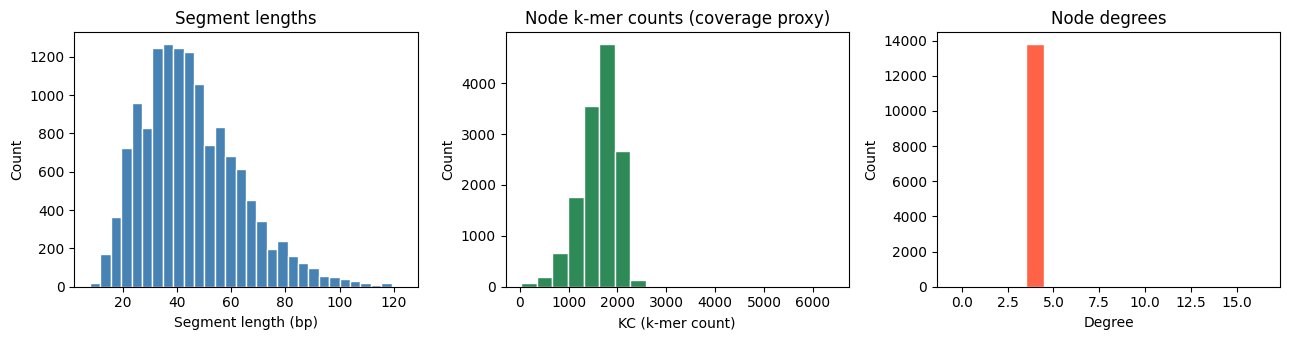

In [25]:
# Segment length distribution
seg_lengths = [graph[i].length for i in graph.node_indices()]
kmer_counts = [graph[i].kmer_count for i in graph.node_indices() if graph[i].kmer_count is not None]
degrees     = [graph.degree(i) for i in graph.node_indices()]

fig, axes = plt.subplots(1, 3, figsize=(13, 3.5))

axes[0].hist(seg_lengths, bins=30, color="steelblue", edgecolor="white")
axes[0].set_xlabel("Segment length (bp)"); axes[0].set_ylabel("Count")
axes[0].set_title("Segment lengths")

axes[1].hist(kmer_counts, bins=20, color="seagreen", edgecolor="white")
axes[1].set_xlabel("KC (k-mer count)"); axes[1].set_ylabel("Count")
axes[1].set_title("Node k-mer counts (coverage proxy)")

axes[2].hist(degrees, bins=range(0, max(degrees) + 2), color="tomato", edgecolor="white", align="left")
axes[2].set_xlabel("Degree"); axes[2].set_ylabel("Count")
axes[2].set_title("Node degrees")

fig.tight_layout()
plt.show()

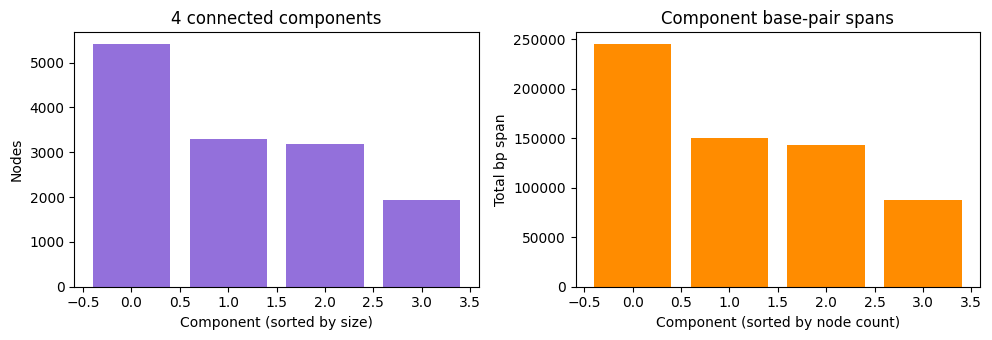

Sizes: [5403, 3296, 3179, 1937]


In [26]:
# Component size distribution
components = sorted(rx.connected_components(graph), key=len, reverse=True)
comp_sizes = [len(c) for c in components]
comp_bp    = [sum(graph[i].length for i in c) for c in components]

fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))

axes[0].bar(range(len(comp_sizes)), comp_sizes, color="mediumpurple")
axes[0].set_xlabel("Component (sorted by size)"); axes[0].set_ylabel("Nodes")
axes[0].set_title(f"{len(components)} connected components")

axes[1].bar(range(len(comp_bp)), comp_bp, color="darkorange")
axes[1].set_xlabel("Component (sorted by node count)"); axes[1].set_ylabel("Total bp span")
axes[1].set_title("Component base-pair spans")

fig.tight_layout()
plt.show()
print("Sizes:", comp_sizes[:5])

## 3  Large-component selection and leaf nodes

In [27]:
SAMPLE_COMPONENT_PROPORTION = 0.5

eligible_nodes, chosen_comps = large_component_nodes(graph, SAMPLE_COMPONENT_PROPORTION)
print(f"Chosen {len(chosen_comps)} component(s), "
      f"{len(eligible_nodes):,} nodes = "
      f"{len(eligible_nodes)/graph.num_nodes():.1%} of {graph.num_nodes()} total")

leaves_all  = leaf_nodes(graph)
leaves_elig = [n for n in leaves_all if n in eligible_nodes]
print(f"Leaf nodes (degree=1): {len(leaves_all)} total, {len(leaves_elig)} in eligible components")

Chosen 2 component(s), 8,699 nodes = 63.0% of 13815 total
Leaf nodes (degree=1): 0 total, 0 in eligible components


## 4  Path sampling

In [28]:
N_PATHS   = 100   # smaller than production (100 000) for speed
WEIGHT    = "kmer"

sampled_paths = sample_paths(graph, N_PATHS, WEIGHT, eligible_nodes)
path_lengths  = [bp for _, bp in sampled_paths]

print(f"Sampled {len(path_lengths)} paths")
print(f"  min={min(path_lengths):,}  max={max(path_lengths):,}  "
      f"mean={np.mean(path_lengths):,.0f}  median={np.median(path_lengths):,.0f} bp")

WARNING No eligible leaf nodes (all degrees > 1); using 8699 eligible nodes as start candidates.


Sampled 100 paths
  min=252  max=22,781  mean=8,508  median=6,128 bp


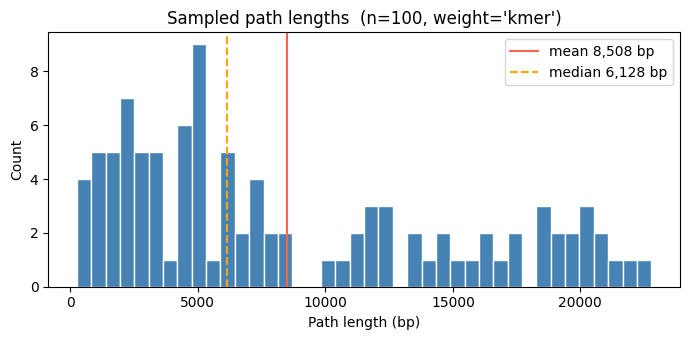

In [29]:
fig, ax = plt.subplots(figsize=(7, 3.5))
ax.hist(path_lengths, bins=40, color="steelblue", edgecolor="white")
ax.axvline(np.mean(path_lengths), color="tomato",  lw=1.5, label=f"mean {np.mean(path_lengths):,.0f} bp")
ax.axvline(np.median(path_lengths), color="orange", lw=1.5, linestyle="--",
           label=f"median {np.median(path_lengths):,.0f} bp")
ax.set_xlabel("Path length (bp)")
ax.set_ylabel("Count")
ax.set_title(f"Sampled path lengths  (n={N_PATHS}, weight={WEIGHT!r})")
ax.legend()
fig.tight_layout()
plt.show()

In [30]:
# Inspect one path in detail
example_path, example_bp = sorted(sampled_paths, key=lambda t: t[1], reverse=True)[0]
print(f"Longest sampled path: {example_bp:,} bp  ({len(example_path)} segments)")
for node_idx, is_fwd in example_path[:10]:
    seg = graph[node_idx]
    print(f"  node {node_idx:4d}  {'+' if is_fwd else '-'}  name={seg.name:>6s}  len={seg.length}")
if len(example_path) > 10:
    print(f"  … ({len(example_path) - 10} more segments)")

Longest sampled path: 22,781 bp  (3093 segments)
  node 10113  -  name=  1507  len=54
  node 3398  -  name=  1508  len=48
  node  608  -  name=  1509  len=44
  node  909  +  name=  1510  len=34
  node 12555  -  name=  1512  len=28
  node 4753  +  name=  1514  len=21
  node 9061  +  name=  1516  len=57
  node 4127  -  name= 13746  len=64
  node 12020  +  name= 13745  len=63
  node 5674  +  name= 13766  len=89
  … (3083 more segments)


## 5  Load the minimizer table

In [31]:
if MIN_TABLE.exists():
    min_table = _load_minimizer_table(MIN_TABLE)
    print(f"Loaded {len(min_table):,} minimizer hash → l-mer entries")
    sample_items = list(min_table.items())[:5]
    for h, lmer in sample_items:
        print(f"  {h:20d}  →  {lmer}")
else:
    min_table = None
    print("minimizer_table not found — exact bp distances unavailable")

INFO Loaded 13698 entries from minimizer table /Users/timrozday/Documents/genome-blender_run/single_short_shallow/output/rust-mdbg/rust_mdbg_out.minimizer_table


Loaded 13,698 minimizer hash → l-mer entries
   1003822484305321045  →  CTGAGTCGCTCATCACGTGAG
   1039620297906419325  →  GAGATCGCACGATGAGTCGTC
    172619147605470118  →  GATGCACATATGAGTCATCAT
    894455465364932785  →  GTACGTCTGATCGAGACGTAG
   1090728500945250483  →  AGAGATAGACACGATCATCTC


## 6  Load node minimizer sequences

INFO Loaded minimizer sequences for 13815 nodes (k=7) from 8 file(s)


Node minimizer sequences loaded for 13,815 segments (13,815 non-empty)  k_val=7


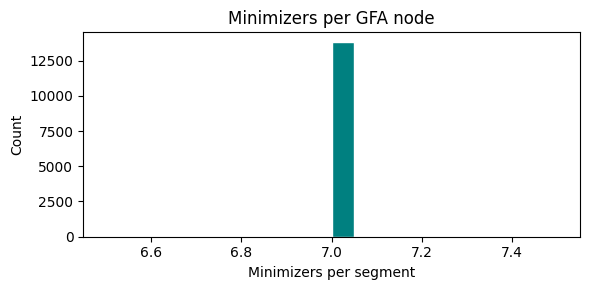

In [32]:
node_min_seqs, k_val = _load_node_minimizer_seqs(PREFIX)
n_segs_with_mins = sum(1 for v in node_min_seqs.values() if len(v) > 0)
print(f"Node minimizer sequences loaded for {len(node_min_seqs):,} segments "
      f"({n_segs_with_mins:,} non-empty)  k_val={k_val}")

# Distribution of minimizers per node
mins_per_node = [len(v) for v in node_min_seqs.values()]
fig, ax = plt.subplots(figsize=(6, 3))
ax.hist([x for x in mins_per_node if x > 0], bins=20, color="teal", edgecolor="white")
ax.set_xlabel("Minimizers per segment")
ax.set_ylabel("Count")
ax.set_title("Minimizers per GFA node")
fig.tight_layout()
plt.show()

## 7  Combination minimizer hashing — visual check

Demonstrates `_compute_kmer_hashes` and hash orientation-invariance.

Path minimizer sequence length: 3099 minimizers
K-mer hashes (k=0):           3099 k-mers
Forward hashes: 3,093   Reverse hashes: 3,093
Intersection:   3,093  (canonical hashes shared by fwd and rev traversal)


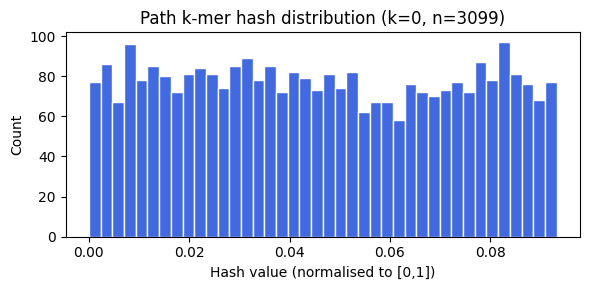

In [33]:
# Build the path minimizer sequence for the longest sampled path.
# This mirrors the inline logic in build_top_path_combo_sketches.
def _build_path_min_seq(path, graph, node_min_seqs, k_val):
    """Concatenate per-node minimizer sequences for a path."""
    min_ids = []
    for seg_i, (node_idx, is_fwd) in enumerate(path):
        mids = node_min_seqs.get(int(graph[node_idx].name))
        if mids is None or len(mids) == 0:
            return None
        node_mids = mids if is_fwd else mids[::-1]
        if seg_i == 0:
            min_ids.extend(node_mids.tolist())
        else:
            overlap = k_val - 1
            new_mids = node_mids[overlap:] if len(node_mids) > overlap else node_mids[-1:]
            min_ids.extend(new_mids.tolist())
    return np.array(min_ids, dtype=np.uint64) if len(min_ids) >= 2 else None

path_min_seqs = None
if node_min_seqs:
    path_min_seqs = _build_path_min_seq(example_path, graph, node_min_seqs, k_val)

if path_min_seqs is None:
    print("No node minimizer sequences available — using node indices as proxy.")
    path_min_seqs = np.array([node_idx for node_idx, _ in example_path], dtype=np.uint64)

print(f"Path minimizer sequence length: {len(path_min_seqs)} minimizers")

kmers = _compute_kmer_hashes(path_min_seqs, k=K) if K>0 else path_min_seqs
print(f"K-mer hashes (k={K}):           {len(kmers)} k-mers")

# Verify orientation invariance: reverse the minimizer sequence → same canonical hashes
kmers_rev = _compute_kmer_hashes(path_min_seqs[::-1], k=K) if K>0 else path_min_seqs[::-1]
fwd_set, rev_set = set(kmers.tolist()), set(kmers_rev.tolist())
print(f"Forward hashes: {len(fwd_set):,}   Reverse hashes: {len(rev_set):,}")
print(f"Intersection:   {len(fwd_set & rev_set):,}  (canonical hashes shared by fwd and rev traversal)")

# Show hash value distribution
fig, ax = plt.subplots(figsize=(6, 3))
ax.hist(kmers.astype(np.float64) / (2**64), bins=40, color="royalblue", edgecolor="white")
ax.set_xlabel("Hash value (normalised to [0,1])")
ax.set_ylabel("Count")
ax.set_title(f"Path k-mer hash distribution (k={K}, n={len(kmers)})")
fig.tight_layout()
plt.show()

Thinning density=0.1  threshold=1,844,674,407,370,955,264
  3,099 k-mers → 3,099 retained (100.00%)


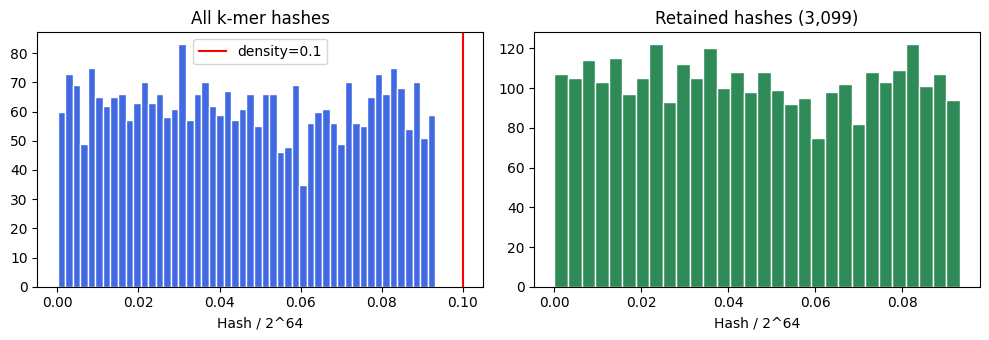

In [34]:
# Thinning: fraction retained at COMBO_DENSITY
threshold = np.uint64(int(_UINT64_MAX * COMBO_DENSITY))
retained = kmers[kmers <= threshold]
print(f"Thinning density={COMBO_DENSITY}  threshold={int(threshold):,}")
print(f"  {len(kmers):,} k-mers → {len(retained):,} retained ({len(retained)/len(kmers):.2%})")

fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
axes[0].hist(kmers.astype(np.float64) / (2**64), bins=50, color="royalblue", edgecolor="white")
axes[0].axvline(COMBO_DENSITY, color="red", lw=1.5, label=f"density={COMBO_DENSITY}")
axes[0].set_title("All k-mer hashes"); axes[0].legend()
axes[0].set_xlabel("Hash / 2^64")

axes[1].hist(retained.astype(np.float64) / (2**64), bins=30, color="seagreen", edgecolor="white")
axes[1].set_title(f"Retained hashes ({len(retained):,})")
axes[1].set_xlabel("Hash / 2^64")

fig.tight_layout()
plt.show()

## 8  Read LMDB — inspect raw minimizer data

Requires `rust_mdbg_out.index.lmdb` (run the setup cell if missing).

First 20 reads:
  read_id=   0  n_minimizers= 16  first_3=[814429673086282161, 480661672702273866, 800205826515057675]
  read_id=   1  n_minimizers= 13  first_3=[1671427474075468504, 1511311747336202583, 1638649315136269765]
  read_id=   2  n_minimizers= 21  first_3=[105989933762580806, 10005986287076409, 1262009247854848704]
  read_id=   3  n_minimizers= 12  first_3=[917605213101478218, 714261432991658952, 449754273939106538]
  read_id=   4  n_minimizers= 12  first_3=[1305785426477284552, 1417371551869884936, 682058104643047379]
  read_id=   5  n_minimizers= 18  first_3=[692742564807516130, 8906516543216414, 299930010475974919]

Total reads in LMDB: 2000000
Minimizers per read: min=5  max=37  mean=17.2


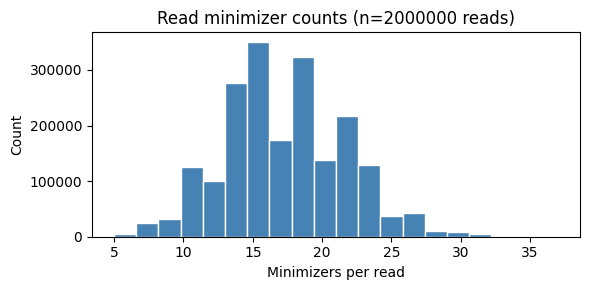

In [35]:
if not LMDB_PATH.exists():
    print("LMDB not found — skipping section 8 onwards.")
else:
    reads_sample = list(_iter_reads_lmdb(LMDB_PATH, limit=20))
    print(f"First {len(reads_sample)} reads:")
    for rid, mids, pos in reads_sample[:6]:
        print(f"  read_id={rid:4d}  n_minimizers={len(mids):3d}  first_3={mids[:3].tolist()}")

    mins_per_read = [len(mids) for _, mids, _ in _iter_reads_lmdb(LMDB_PATH)]
    print(f"\nTotal reads in LMDB: {len(mins_per_read)}")
    print(f"Minimizers per read: min={min(mins_per_read)}  max={max(mins_per_read)}  "
          f"mean={np.mean(mins_per_read):.1f}")

    fig, ax = plt.subplots(figsize=(6, 3))
    ax.hist(mins_per_read, bins=20, color="steelblue", edgecolor="white")
    ax.set_xlabel("Minimizers per read")
    ax.set_ylabel("Count")
    ax.set_title(f"Read minimizer counts (n={len(mins_per_read)} reads)")
    fig.tight_layout()
    plt.show()

In [36]:
path_mins: set = set()
for example_path, example_bp in sorted(sampled_paths, key=lambda t: t[1], reverse=True)[:100]:
    path_min_seqs = _build_path_min_seq(example_path, graph, node_min_seqs, k_val)
    path_mins.update(path_min_seqs)
    
reads_mins: set = {v for _, mids, _ in _iter_reads_lmdb(LMDB_PATH) for v in mids}

len(path_mins-reads_mins), len(path_mins & reads_mins), len(reads_mins-path_mins)

(0, 8592, 5106)

## 9  PE combination minimizer sketch

INFO PE combo thinning: threshold=1844674407370955264 density=0.1000


PE combo sketch: 200,374 unique hashes


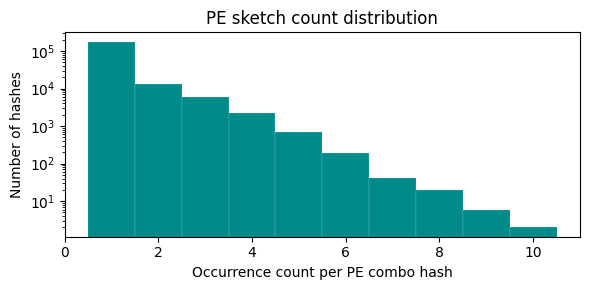

In [37]:
if not LMDB_PATH.exists():
    print("LMDB not found — skipping.")
else:
    pe_sketch = build_pe_combo_sketch(
        LMDB_PATH, density=COMBO_DENSITY, k=K,
        out_lmdb=PE_LMDB if not PE_LMDB.exists() else None,
        max_distance=0,
        # limit=1_000_000
    )
    # if PE_LMDB.exists() and pe_sketch._env is None:
    #     # load from disk if we didn't rebuild it
    #     pe_sketch = CombSketchIndex(lmdb_path=PE_LMDB)

    print(f"PE combo sketch: {len(pe_sketch):,} unique hashes")

    # Count distribution
    pe_counts = list(pe_sketch._buf.values()) if pe_sketch._env is None else []
    if pe_counts:
        fig, ax = plt.subplots(figsize=(6, 3))
        ax.hist(pe_counts, bins=range(1, max(pe_counts) + 2), color="darkcyan", edgecolor="white", lw=0.1, align="left")
        ax.set_xlabel("Occurrence count per PE combo hash")
        ax.set_ylabel("Number of hashes")
        ax.set_title("PE sketch count distribution")
        ax.set_yscale("log")
        fig.tight_layout()
        plt.show()
    else:
        print("(PE sketch is LMDB-backed — count histogram skipped)")

## 10  Intra-read combination minimizer sketch

INFO Intra combo thinning: threshold=1844674407370955264 density=0.1000


Intra combo sketch: 23,331 unique hashes
PE ∩ Intra: 408 hashes  (0.20% of PE, 1.75% of Intra)


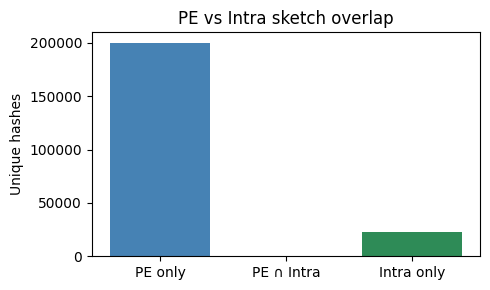

In [38]:
if not LMDB_PATH.exists():
    print("LMDB not found — skipping.")
else:
    intra_sketch = build_intra_combo_sketch(
        LMDB_PATH, density=COMBO_DENSITY, k=K,
        out_lmdb=INTRA_LMDB if not INTRA_LMDB.exists() else None,
        # limit=1_000_000
    )
    print(f"Intra combo sketch: {len(intra_sketch):,} unique hashes")

    # Overlap between PE and intra sketches
    if pe_sketch._env is None and intra_sketch._env is None:
        pe_set    = set(pe_sketch._buf.keys())
        intra_set = set(intra_sketch._buf.keys())
        overlap   = len(pe_set & intra_set)
        print(f"PE ∩ Intra: {overlap:,} hashes  "
              f"({overlap / len(pe_set):.2%} of PE, {overlap / len(intra_set):.2%} of Intra)")

        fig, ax = plt.subplots(figsize=(5, 3))
        sizes = [len(pe_set) - overlap, overlap, len(intra_set) - overlap]
        labels = ["PE only", "PE ∩ Intra", "Intra only"]
        ax.bar(labels, sizes, color=["steelblue", "purple", "seagreen"])
        ax.set_ylabel("Unique hashes")
        ax.set_title("PE vs Intra sketch overlap")
        fig.tight_layout()
        plt.show()

## 11  Build path combo sketches

For each of the top-N longest sampled paths, builds a distance-binned
combination minimizer sketch.

/Users/timrozday/miniforge3/envs/genome_blender_dev/lib/python3.14/site-packages/rich/live.py:260: UserWarning: 
install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

INFO Loaded minimizer sequences for 13815 nodes (k=7) from 8 file(s)
INFO Estimated bp_scale=7.33 from 100 top path(s)


INFO Built path combo sketches for 100/100 paths


bp_scale = 7.33 bp / minimizer
Paths with sketches: 100


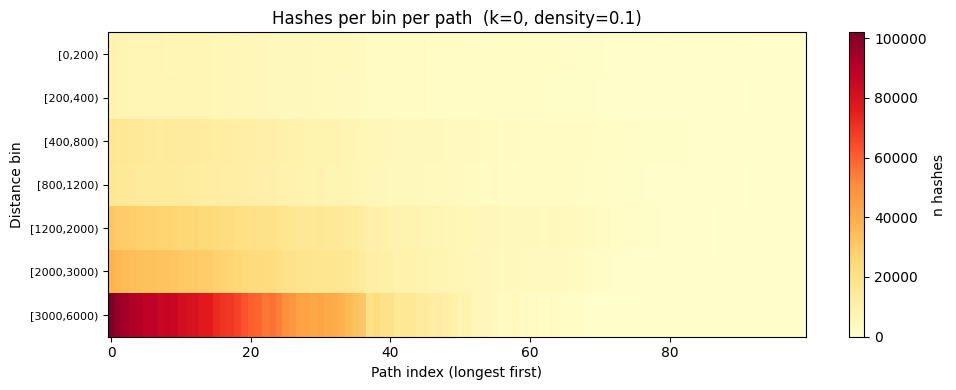

In [504]:
if not LMDB_PATH.exists():
    print("LMDB not found — skipping.")
else:
    INSERT_SIZE_PATHS = 100   # use fewer paths than production for speed

    top_paths_sorted = sorted(sampled_paths, key=lambda t: t[1], reverse=True)

    path_bin_sketches, bp_scale = build_top_path_combo_sketches(
        use_exact_distances=True,
        graph=graph,
        lmdb_path=LMDB_PATH,
        bin_distances=INSERT_BINS,
        density=COMBO_DENSITY,
        n_paths=INSERT_SIZE_PATHS,
        top_paths=top_paths_sorted,
        k=K,
        min_table=min_table,
        l=L,
        seqs_prefix=PREFIX,
    )

    print(f"bp_scale = {bp_scale:.2f} bp / minimizer")
    print(f"Paths with sketches: {len(path_bin_sketches)}")

    # Hashes per bin per path
    hashes_per_bin_per_path = [
        [len(sketch._buf) for sketch in path_sketch]
        for path_sketch in path_bin_sketches
    ]
    hpp_arr = np.array(hashes_per_bin_per_path)   # [n_paths, n_bins]
    bin_labels = [f"[{INSERT_BINS[i]:.0f},{INSERT_BINS[i+1]:.0f})" for i in range(len(INSERT_BINS)-1)]

    fig, ax = plt.subplots(figsize=(10, 4))
    im = ax.imshow(hpp_arr.T, aspect="auto", cmap="YlOrRd", origin="upper")
    ax.set_xlabel("Path index (longest first)")
    ax.set_ylabel("Distance bin")
    ax.set_yticks(range(len(bin_labels)))
    ax.set_yticklabels(bin_labels, fontsize=8)
    ax.set_title(f"Hashes per bin per path  (k={K}, density={COMBO_DENSITY})")
    plt.colorbar(im, ax=ax, label="n hashes")
    fig.tight_layout()
    plt.show()

### Ideal path (reference)

In [50]:
# ── Homopolymer compression (replicates rust-mdbg encode_rle) ────────────────

def _encode_rle(seq: str | bytes) -> tuple[bytes, list[int]]:
    """Homopolymer-compress *seq*, replicating rust-mdbg's ``encode_rle``.

    Consecutive identical bases in ``ACTGactgNn`` are collapsed to a single
    copy.  The returned position list maps each compressed base back to its
    start position in the original sequence.

    Returns:
        ``(hpc_bytes, positions)`` where ``positions[i]`` is the 0-based
        index in *seq* of the first occurrence of the *i*-th HPC base.
    """
    if isinstance(seq, str):
        seq = seq.encode()
    hpc = bytearray()
    positions: list[int] = []
    prev_c: int | None = None
    run_start = 0
    for i, c in enumerate(seq):
        if prev_c is not None and c == prev_c and chr(c) in "ACTGactgNn":
            continue  # extend homopolymer run — skip
        if prev_c is not None:
            hpc.append(prev_c)
            positions.append(run_start)
        prev_c = c
        run_start = i
    if prev_c is not None:
        hpc.append(prev_c)
        positions.append(run_start)
    return bytes(hpc), positions


# ── Minimizer extraction (replicates rust-mdbg extract_density) ─────────────

def seq_to_minimizers(
    seq: str | bytes,
    l: int,
    density: float,
) -> tuple[np.ndarray, np.ndarray]:
    """Extract minimizer IDs and positions from a DNA sequence.

    Replicates rust-mdbg's density-based l-mer selection (``extract_density``):

    1. Homopolymer-compress the sequence with ``_encode_rle``.
    2. Compute canonical rolling ntHash for every l-mer in the HPC sequence
       using :func:`nthash_seq`.
    3. Retain l-mers whose hash is ``≤ density × (2⁶⁴ − 1)``.
    4. Skip l-mers containing ``'N'`` or ``'n'``.

    Returned positions are 0-based coordinates in the *original* (non-HPC)
    sequence, matching the ``minimizer_pos`` values recorded by rust-mdbg.

    Args:
        seq:     Input DNA sequence (str or bytes; upper or lower case).
        l:       l-mer length (``--l`` in rust-mdbg).
        density: Fraction of l-mers selected as minimizers (``--density``).

    Returns:
        ``(min_ids, min_positions)`` — both 1-D numpy arrays:

        * ``min_ids``       — uint64 canonical ntHash values (minimizer IDs).
        * ``min_positions`` — int64 0-based positions in the *original* sequence.
    """
    if isinstance(seq, str):
        seq = seq.encode()

    hpc_seq, hpc_positions = _encode_rle(seq)

    if len(hpc_seq) < l:
        return np.empty(0, dtype=np.uint64), np.empty(0, dtype=np.int64)

    threshold = int(density * _MASK64)
    all_hashes = nthash_seq(hpc_seq, l)

    min_ids: list[int] = []
    min_pos: list[int] = []
    for i, h in enumerate(all_hashes):
        if h > threshold:
            continue
        if b"N" in hpc_seq[i : i + l] or b"n" in hpc_seq[i : i + l]:
            continue
        min_ids.append(h)
        min_pos.append(hpc_positions[i])

    return np.array(min_ids, dtype=np.uint64), np.array(min_pos, dtype=np.int64)


# ----- quick sanity check -----
_test_seq = b"AACGGT"
_test_hpc, _test_pos = _encode_rle(_test_seq)
assert _test_hpc == b"ACGT", f"HPC mismatch: {_test_hpc}"
assert _test_pos == [0, 2, 3, 5], f"HPC pos mismatch: {_test_pos}"
_test_mids, _test_mpos = seq_to_minimizers(b"ACGTACGTACGT", l=4, density=1.0)
assert len(_test_mids) == 9, f"Expected 9 minimizers for density=1.0: {len(_test_mids)}"
print("seq_to_minimizers sanity checks passed.")


seq_to_minimizers sanity checks passed.


In [ ]:
def build_ref_combo_sketches(
    seq: str | bytes,
    bin_distances: list[float],
    combo_density: float,
    minimizer_density: float,
    l: int = L,
    k: int = K,
) -> list[CombSketchIndex]:
    """Build distance-binned combination minimizer sketches for a reference sequence.

    Analogous to :func:`build_path_combo_sketch` with ``use_exact_distances=True``,
    but operates directly on a nucleotide sequence rather than a GFA graph path.
    Because exact base-pair positions of every minimizer are known from the
    sequence, no ``bp_scale`` approximation is needed.

    For every ordered pair of minimizer-space k-mer hashes ``(i, j)``
    (``i < j``) whose leading-minimizer positions span a distance within
    ``[bin_distances[0], bin_distances[-1]]`` bp, a canonical combination hash
    is computed and — if it survives thinning — added to the bin sketch that
    covers that distance.  Each unique combo hash is assigned to at most one
    bin (multi-bin duplicates are discarded), matching the deduplication logic
    in :func:`build_path_combo_sketch`.

    Args:
        seq:               Reference DNA sequence (str or bytes).
        bin_distances:     Sorted bp breakpoints defining bins; must have ≥ 2
                           values, e.g. ``INSERT_BINS``.
        combo_density:     Thinning fraction for combination hashes
                           (``COMBO_DENSITY`` in the notebook).
        minimizer_density: Fraction of l-mers selected as minimizers; must
                           match the ``--density`` value used by rust-mdbg.
        l:                 l-mer length (``--l``; default ``L``).
        k:                 Minimizer k-mer order (``--combo-k`` / ``K``).

    Returns:
        List of :class:`CombSketchIndex`, one per bin
        (length = ``len(bin_distances) − 1``).
    """
    if len(bin_distances) < 2:
        raise ValueError("bin_distances must have at least 2 values")

    min_ids, min_pos = seq_to_minimizers(seq, l=l, density=minimizer_density)
    n_bins = len(bin_distances) - 1
    sketches: list[CombSketchIndex] = [CombSketchIndex() for _ in range(n_bins)]

    kmer_hashes = _compute_kmer_hashes(min_ids, k)
    if len(kmer_hashes) < 2:
        return sketches

    # Exact bp positions for each k-mer = position of its leading minimizer.
    kmer_pos = min_pos[: len(kmer_hashes)].astype(np.float64)
    bin_arr = np.array(bin_distances, dtype=np.float64)
    threshold = np.uint64(int(_UINT64_MAX * combo_density))
    n = len(kmer_hashes)

    # Each combo hash is assigned to exactly one bin (first-seen wins).
    # If a hash appears at two different distances in different bins it is
    # discarded (-1), matching build_path_combo_sketch exact-distance logic.
    hash_to_bin: dict[int, int] = {}

    for i in range(n):
        pos_i = kmer_pos[i]
        j_lo = int(np.searchsorted(kmer_pos, pos_i + bin_distances[0], side="left"))
        j_hi = int(np.searchsorted(kmer_pos, pos_i + bin_distances[-1], side="right")) - 1
        j_lo = max(j_lo, i + 1)
        if j_lo > j_hi:
            continue

        j_range = np.arange(j_lo, j_hi + 1, dtype=np.intp)
        a_arr = np.full(len(j_range), kmer_hashes[i], dtype=np.uint64)
        hashes = _canonical_combo_hash_v(a_arr, kmer_hashes[j_range])

        keep = hashes <= threshold
        if not np.any(keep):
            continue

        kept_hashes = hashes[keep]
        kept_dists = kmer_pos[j_range[keep]] - pos_i
        bin_indices = np.searchsorted(bin_arr, kept_dists, side="right") - 1

        for h_val, b_idx in zip(kept_hashes.tolist(), bin_indices.tolist()):
            if 0 <= b_idx < n_bins:
                if h_val in hash_to_bin:
                    if hash_to_bin[h_val] != b_idx:
                        hash_to_bin[h_val] = -1  # multi-bin conflict — discard
                else:
                    hash_to_bin[h_val] = b_idx

    for h_val, b_idx in hash_to_bin.items():
        if b_idx >= 0:
            sketches[b_idx].increment(h_val)

    return sketches

In [76]:
def read_fasta(filehandle, target_seqs=None, split_header=False):
    header = None
    seq_lines = []
    
    with filehandle as f:
        for l in f:
            if l[0]=='>':
                if not header is None:
                    if (target_seqs is None) or ((target_seqs is not None) and (header in target_seqs)):
                        yield header, ''.join(seq_lines)
                header = l.strip()[1:].split()[0]
                if split_header:
                    header = header.split()[0]
                seq_lines = []
            else:
                if l.strip():
                    seq_lines.append(l.strip())
        else:
            if (target_seqs is None) or ((target_seqs is not None) and (header in target_seqs)):
                yield header, ''.join(seq_lines)

with open('../../genome-blender_run/single_short_shallow/seqs/MGYG000290000_1.fna', 'rt') as f:
    seqs = {k:v for k,v in read_fasta(f)}
seqs.keys()

dict_keys(['MGYG000290000_1'])

In [83]:
seqs['MGYG000290000_1'][:10].encode('utf8')

b'CTTAAAGGGG'

In [84]:
path_bin_sketch = build_ref_combo_sketches(
    seqs['MGYG000290000_1'].encode('utf8'), 
    bin_distances=INSERT_BINS,
    combo_density=COMBO_DENSITY,
    minimizer_density=0.1378,
    l=L,
    k=K,
)

IndexError: index 0 is out of bounds for axis 1 with size 0

## 12  Aggregate path bin sketches

/Users/timrozday/miniforge3/envs/genome_blender_dev/lib/python3.14/site-packages/rich/live.py:260: UserWarning: 
install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

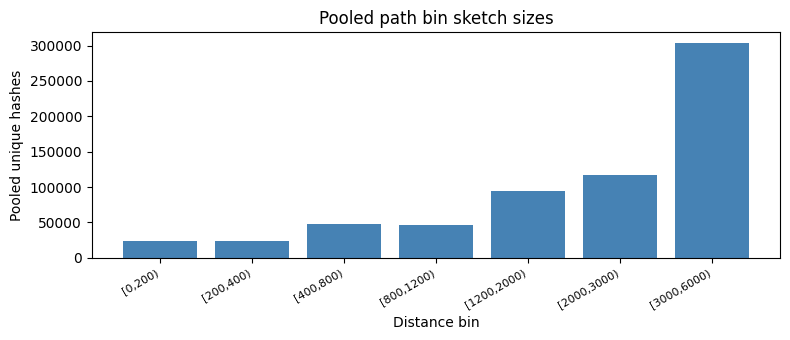

  bin 0:              [0,200)  23,023 hashes
  bin 1:            [200,400)  23,331 hashes
  bin 2:            [400,800)  47,727 hashes
  bin 3:           [800,1200)  46,821 hashes
  bin 4:          [1200,2000)  94,552 hashes
  bin 5:          [2000,3000)  116,900 hashes
  bin 6:          [3000,6000)  303,652 hashes


In [505]:
if not LMDB_PATH.exists() or not path_bin_sketches:
    print("Skipping.")
else:
    pooled = aggregate_path_bin_sketches(path_bin_sketches)
    pooled_sizes = [len(s) for s in pooled]

    fig, ax = plt.subplots(figsize=(8, 3.5))
    ax.bar(range(len(pooled_sizes)), pooled_sizes, color="steelblue",
           tick_label=bin_labels)
    ax.set_xlabel("Distance bin")
    ax.set_ylabel("Pooled unique hashes")
    ax.set_title("Pooled path bin sketch sizes")
    plt.xticks(rotation=30, ha="right", fontsize=8)
    fig.tight_layout()
    plt.show()

    for i, (label, n) in enumerate(zip(bin_labels, pooled_sizes)):
        print(f"  bin {i}: {label:>20s}  {n:,} hashes")

## 13  Containment rates — PE sketch vs path bins

PE sketch unique hashes: 23,331

                      Bin    n_path   pe_hits     c_obs
                  [0,200)    22,759    14,435    0.6343
                [200,400)    22,828        22    0.0010
                [400,800)    45,233         0    0.0000
               [800,1200)    45,498         0    0.0000
              [1200,2000)    88,234         0    0.0000
              [2000,3000)   106,613         9    0.0001
              [3000,6000)   289,600        30    0.0001


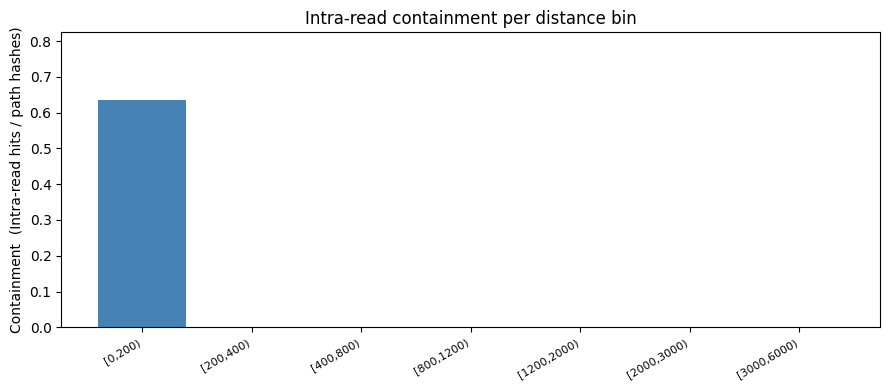

In [245]:
if not LMDB_PATH.exists() or not path_bin_sketches:
    print("Skipping.")
else:
    c_obs, c_noise, n_pe = compute_containment_rates(intra_sketch, pooled, None)
    print(f"PE sketch unique hashes: {n_pe:,}")
    print()
    print(f"{'Bin':>25s}  {'n_path':>8s}  {'pe_hits':>8s}  {'c_obs':>8s}")
    for i, label in enumerate(bin_labels):
        n = pooled_sizes[i]
        hits = round(c_obs[i] * n) if not np.isnan(c_obs[i]) else 0
        c_str = f"{c_obs[i]:.4f}" if not np.isnan(c_obs[i]) else "  NaN "
        print(f"  {label:>23s}  {n:>8,}  {hits:>8,}  {c_str:>8s}")

    fig, ax = plt.subplots(figsize=(9, 4))
    x = np.arange(len(bin_labels))
    c_plot = np.where(np.isnan(c_obs), 0, c_obs)
    bars = ax.bar(x, c_plot, color=["steelblue" if not np.isnan(v) else "lightgrey" for v in c_obs])
    ax.set_xticks(x)
    ax.set_xticklabels(bin_labels, rotation=30, ha="right", fontsize=8)
    ax.set_ylabel("Containment  (Intra-read hits / path hashes)")
    ax.set_ylim(0, max(0.05, float(np.nanmax(c_obs)) * 1.3))
    ax.set_title("Intra-read containment per distance bin")
    fig.tight_layout()
    plt.show()

PE sketch unique hashes: 200,374

                      Bin    n_path   pe_hits     c_obs
                  [0,200)    22,759       398    0.0175
                [200,400)    22,828     7,120    0.3119
                [400,800)    45,233    17,541    0.3878
               [800,1200)    45,498       870    0.0191
              [1200,2000)    88,234     1,612    0.0183
              [2000,3000)   106,613     1,923    0.0180
              [3000,6000)   289,600     5,253    0.0181


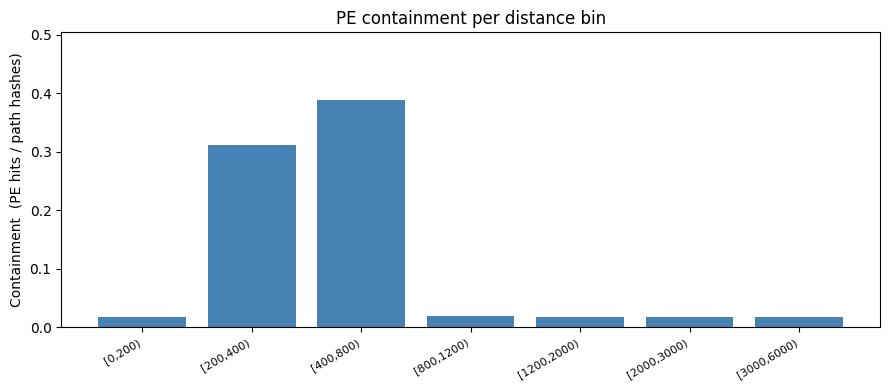

In [246]:
if not LMDB_PATH.exists() or not path_bin_sketches:
    print("Skipping.")
else:
    c_obs, n_pe = compute_containment_rates(pe_sketch, pooled, None)
    print(f"PE sketch unique hashes: {n_pe:,}")
    print()
    print(f"{'Bin':>25s}  {'n_path':>8s}  {'pe_hits':>8s}  {'c_obs':>8s}")
    for i, label in enumerate(bin_labels):
        n = pooled_sizes[i]
        hits = round(c_obs[i] * n) if not np.isnan(c_obs[i]) else 0
        c_str = f"{c_obs[i]:.4f}" if not np.isnan(c_obs[i]) else "  NaN "
        print(f"  {label:>23s}  {n:>8,}  {hits:>8,}  {c_str:>8s}")

    fig, ax = plt.subplots(figsize=(9, 4))
    x = np.arange(len(bin_labels))
    c_plot = np.where(np.isnan(c_obs), 0, c_obs)
    bars = ax.bar(x, c_plot, color=["steelblue" if not np.isnan(v) else "lightgrey" for v in c_obs])
    ax.set_xticks(x)
    ax.set_xticklabels(bin_labels, rotation=30, ha="right", fontsize=8)
    ax.set_ylabel("Containment  (PE hits / path hashes)")
    ax.set_ylim(0, max(0.05, float(np.nanmax(c_obs)) * 1.3))
    ax.set_title("PE containment per distance bin")
    fig.tight_layout()
    plt.show()

## 14  Fragment length inference (Bayesian)

In [706]:
if not LMDB_PATH.exists() or not path_bin_sketches:
    print("Skipping.")
else:
    try:
        _pyro.clear_param_store()
        result = estimate_fragment_length(
            pe_sketch=pe_sketch,
            path_bin_sketches=path_bin_sketches,
            bin_distances=INSERT_BINS,
            read_length=150,
            min_path_hashes_per_bin=10,   # lower threshold for tiny dataset
            inference="nuts",
            num_samples=100,
            num_warmup=100,
        )
        reliable_tag = "" if result.signal_reliable else "  [UNRELIABLE]"
        print(f"Fragment length estimate{reliable_tag}")
        print(f"  median    = {result.median:.0f} bp")
        print(f"  mean      = {result.mean:.0f} bp")
        print(f"  mu_log    = {result.mu_log:.3f}  95% CI [{result.mu_log_ci[0]:.3f}, {result.mu_log_ci[1]:.3f}]")
        print(f"  sig_log   = {result.sigma_log:.3f}  95% CI [{result.sigma_log_ci[0]:.3f}, {result.sigma_log_ci[1]:.3f}]")
        print(f"  rho       = {result.rho:.3f}")
        print(f"  norm      = {result.norm:.3f}")
        print(f"  sigma_obs = {result.sigma_obs:.3f}")
        print(f"  bins_used = {result.n_bins_used}  inference = {result.inference}")
    except Exception as exc:
        print(f"Inference failed: {exc}")
        result = None

INFO PE sketch: 200374 unique hashes; per-path containment rates (mean per bin): [0.0181 0.3003 0.4164 0.0191 0.025  0.0208 0.017 ]
Sample: 100%|██████████████████████████████████████████| 200/200 [00:07, 25.63it/s, step size=1.22e-01, acc. prob=0.914]                                       

Fragment length estimate
  median    = 417 bp
  mean      = 417 bp
  mu_log    = 416.559  95% CI [406.248, 425.851]
  sig_log   = 0.192  95% CI [0.079, 0.277]
  rho       = 0.018
  norm      = 0.687
  sigma_obs = 0.050
  bins_used = 7  inference = nuts


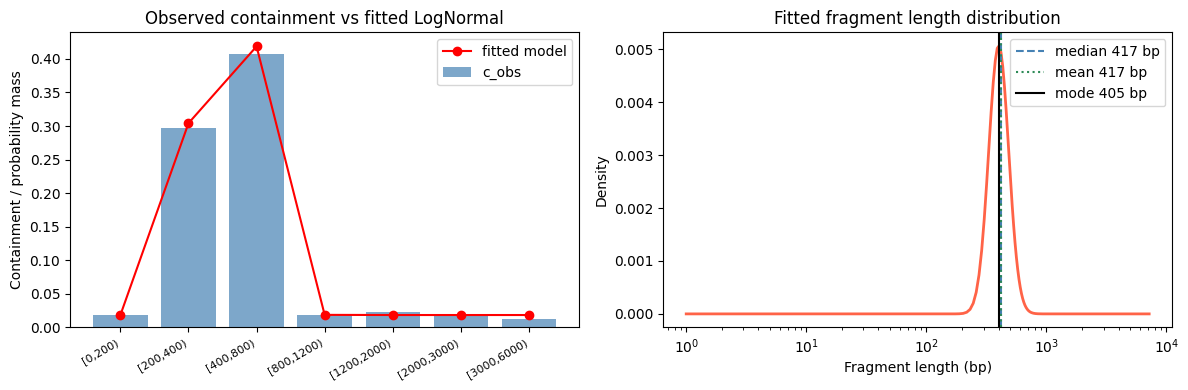

In [707]:
if result is not None:
    import torch
    from torch.distributions import LogNormal

    # Plot fitted log-normal over observed containment
    bin_lo = np.array(INSERT_BINS[:-1], dtype=np.float32)
    bin_hi = np.array(INSERT_BINS[1:],  dtype=np.float32)
    bin_mid = (bin_lo + bin_hi) / 2

    dist = LogNormal(torch.tensor(np.log(result.mu_log)), torch.tensor(result.sigma_log))
    p_fit = (dist.cdf(torch.tensor(bin_hi)) - dist.cdf(torch.tensor(bin_lo))).numpy()
    expected_fit = p_fit * result.norm + result.rho

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # Containment plot
    c_valid = np.where(np.isnan(c_obs), 0, c_obs)
    axes[0].bar(range(len(bin_labels)), c_valid.mean(axis=0), label="c_obs", alpha=0.7, color="steelblue")
    axes[0].plot(range(len(bin_labels)), expected_fit, "ro-", label="fitted model", lw=1.5)
    axes[0].set_xticks(range(len(bin_labels)))
    axes[0].set_xticklabels(bin_labels, rotation=30, ha="right", fontsize=8)
    axes[0].set_ylabel("Containment / probability mass")
    axes[0].set_title("Observed containment vs fitted LogNormal")
    axes[0].legend()

    # LogNormal density
    xs = np.linspace(1, INSERT_BINS[-1] * 1.2, 500)
    ys = np.exp(dist.log_prob(torch.tensor(xs, dtype=torch.float32)).numpy())
    mode = xs[np.argmax(ys)]
    axes[1].plot(xs, ys, color="tomato", lw=2)
    axes[1].axvline(result.median, color="steelblue", lw=1.5, linestyle="--",
                    label=f"median {result.median:.0f} bp")
    axes[1].axvline(result.mean,   color="seagreen",  lw=1.5, linestyle=":",
                    label=f"mean {result.mean:.0f} bp")
    axes[1].axvline(mode,   color="black",  lw=1.5, linestyle="-",
                    label=f"mode {mode:.0f} bp")
    axes[1].set_xlabel("Fragment length (bp)")
    axes[1].set_ylabel("Density")
    axes[1].set_title("Fitted fragment length distribution")
    axes[1].set_xscale('log')
    axes[1].legend()

    fig.tight_layout()
    plt.show()

In [432]:
if not LMDB_PATH.exists() or not path_bin_sketches:
    print("Skipping.")
else:
    try:
        result = estimate_fragment_length_map(
            pe_sketch=pe_sketch,
            path_bin_sketches=path_bin_sketches,
            bin_distances=INSERT_BINS,
            intra_sketch=None,
            min_path_hashes_per_bin=10,   # lower threshold for tiny dataset
            num_steps = 2000,
            lr = 0.01
        )
        reliable_tag = "" if result.signal_reliable else "  [UNRELIABLE]"
        print(f"Fragment length estimate{reliable_tag}")
        print(f"  median    = {result.median:.0f} bp")
        print(f"  mean      = {result.mean:.0f} bp")
        print(f"  mu_log    = {result.mu_log:.3f}")
        print(f"  sig_log   = {result.sigma_log:.3f}")
        print(f"  rho       = {result.rho:.3f}")
        print(f"  bins_used = {result.n_bins_used}")
    except Exception as exc:
        print(f"Inference failed: {exc}")
        result = None

INFO PE sketch: 200374 unique hashes; per-path containment rates (mean per bin): [0.016  0.3149 0.3955 0.0182 0.0174 0.0177 0.0178]


/Users/timrozday/miniforge3/envs/genome_blender_dev/lib/python3.14/site-packages/rich/live.py:260: UserWarning: 
install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Fragment length estimate
  median    = 90028686 bp
  mean      = 90035217 bp
  mu_log    = 18.316
  sig_log   = 0.012
  rho       = 0.112
  bins_used = 7


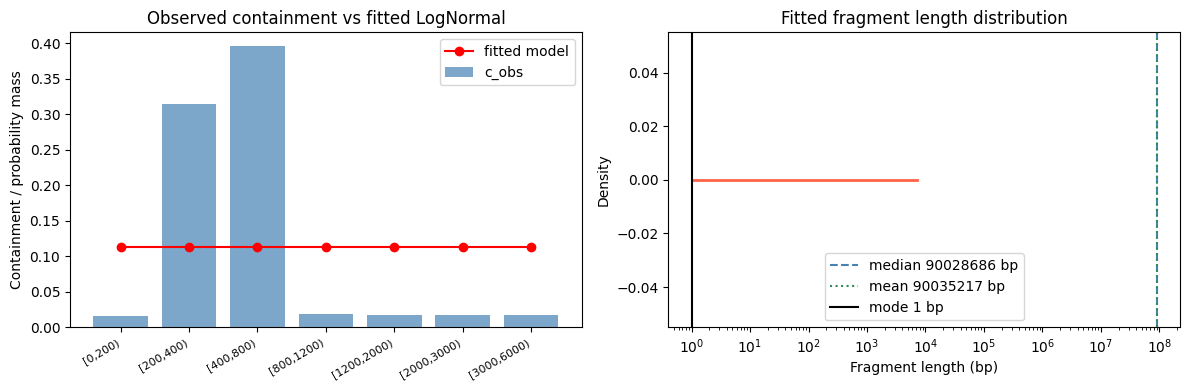

In [433]:
if result is not None:
    import torch
    from torch.distributions import LogNormal

    # Plot fitted log-normal over observed containment
    bin_lo = np.array(INSERT_BINS[:-1], dtype=np.float32)
    bin_hi = np.array(INSERT_BINS[1:],  dtype=np.float32)
    bin_mid = (bin_lo + bin_hi) / 2

    dist = LogNormal(torch.tensor(result.mu_log), torch.tensor(result.sigma_log))
    p_fit = (dist.cdf(torch.tensor(bin_hi)) - dist.cdf(torch.tensor(bin_lo))).numpy()
    expected_fit = p_fit * (1.0 - result.rho) + result.rho

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # Containment plot
    c_valid = np.where(np.isnan(c_obs), 0, c_obs)
    axes[0].bar(range(len(bin_labels)), c_valid.mean(axis=0), label="c_obs", alpha=0.7, color="steelblue")
    axes[0].plot(range(len(bin_labels)), expected_fit, "ro-", label="fitted model", lw=1.5)
    axes[0].set_xticks(range(len(bin_labels)))
    axes[0].set_xticklabels(bin_labels, rotation=30, ha="right", fontsize=8)
    axes[0].set_ylabel("Containment / probability mass")
    axes[0].set_title("Observed containment vs fitted LogNormal")
    axes[0].legend()

    # LogNormal density
    xs = np.linspace(1, INSERT_BINS[-1] * 1.2, 500)
    ys = np.exp(dist.log_prob(torch.tensor(xs, dtype=torch.float32)).numpy())
    mode = xs[np.argmax(ys)]
    axes[1].plot(xs, ys, color="tomato", lw=2)
    axes[1].axvline(result.median, color="steelblue", lw=1.5, linestyle="--",
                    label=f"median {result.median:.0f} bp")
    axes[1].axvline(result.mean,   color="seagreen",  lw=1.5, linestyle=":",
                    label=f"mean {result.mean:.0f} bp")
    axes[1].axvline(mode,   color="black",  lw=1.5, linestyle="-",
                    label=f"mode {mode:.0f} bp")
    axes[1].set_xlabel("Fragment length (bp)")
    axes[1].set_ylabel("Density")
    axes[1].set_title("Fitted fragment length distribution")
    axes[1].set_xscale('log')
    axes[1].legend()

    fig.tight_layout()
    plt.show()

## 15  Graph summary statistics

In [48]:
print_summary(graph, path_lengths, WEIGHT)

print()
summary = _compute_summary(graph, path_lengths, WEIGHT)
print("JSON summary:")
print(json.dumps(summary, indent=2))

Nodes (segments): 16089
Edges (links):    32242
Connected components: n=1, min=16089, max=16089, mean=16089, median=16089, std_dev=0
Total assembly span: 630,841 bp
Segment lengths:  min=9, max=114, mean=39
Node degrees:     min=2, max=40, mean=4.0
K-mer counts:     min=3, max=514, mean=164

Sampled path lengths (1,000 samples, kmer weights, bp):
  min:      283
  max:      556,881
  mean:     145,474
  std dev:  103,258
  variance: 10,662,202,369

JSON summary:
{
  "nodes": 16089,
  "edges": 32242,
  "connected_components": 1,
  "component_nodes_min": 16089,
  "component_nodes_max": 16089,
  "component_nodes_mean": 16089.0,
  "component_nodes_median": 16089,
  "component_nodes_std_dev": 0.0,
  "total_assembly_bp": 630841,
  "segment_length_min": 9,
  "segment_length_max": 114,
  "segment_length_mean": 39.20945987942072,
  "degree_min": 2,
  "degree_max": 40,
  "degree_mean": 4.007955746161974,
  "kmer_count_min": 3,
  "kmer_count_max": 514,
  "kmer_count_mean": 163.89663745416124,
  "

## 16  Compare with existing graph_summary.json

In [ ]:
existing_json = PREFIX.with_name(PREFIX.name + ".graph_summary.json")
if existing_json.exists():
    existing = json.loads(existing_json.read_text())
    print(f"{'Key':<35s}  {'existing':>12s}  {'notebook':>12s}")
    print("-" * 62)
    keys_to_compare = [
        "nodes", "edges", "connected_components",
        "total_assembly_bp", "segment_length_min", "segment_length_max",
        "degree_min", "degree_max",
    ]
    for key in keys_to_compare:
        ev = existing.get(key, "—")
        nv = summary.get(key, "—")
        match = "✓" if ev == nv else "✗"
        print(f"  {match} {key:<33s}  {str(ev):>12s}  {str(nv):>12s}")
else:
    print("graph_summary.json not found.")

## 17  Cleanup

In [ ]:
# Close LMDB handles to avoid resource leaks
try:
    pe_sketch.close()
except NameError:
    pass
try:
    intra_sketch.close()
except NameError:
    pass
print("Done.")